In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import math
import json
import pandas as pd
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error, r2_score
from typing import Dict, List, Tuple, Optional, Set
import pandas as pd
import warnings
import seaborn as sns
from matplotlib.colors import ListedColormap
from typing import Dict, List, Tuple
warnings.filterwarnings("ignore")

In [10]:
class CellDataProcessor:
    def __init__(self, data_dir: str = "CellData", adj_dir: str = "adj"):
        self.data_dir = data_dir 
        self.adj_dir = adj_dir    
        self.cell_relations = {
            'ABa': {'mother': 'AB', 'daughters': ['ABal', 'ABar']},
            'ABp': {'mother': 'AB', 'daughters': ['ABpl', 'ABpr']},
            'EMS': {'mother': 'P1', 'daughters': ['E', 'MS']},
            'P2': {'mother': 'P1', 'daughters': ['C', 'P3']},
            'ABal': {'mother': 'ABa', 'daughters': []},
            'ABar': {'mother': 'ABa', 'daughters': []},
            'ABpl': {'mother': 'ABp', 'daughters': []},
            'ABpr': {'mother': 'ABp', 'daughters': []},
            'E': {'mother': 'EMS', 'daughters': []},
            'MS': {'mother': 'EMS', 'daughters': []},
            'C': {'mother': 'P2', 'daughters': []},
            'P3': {'mother': 'P2', 'daughters': []}
        }
        self.group_time_mapping = {
            'G1': 0,
            'G2': 1,
            'G3': 2,
            'G4': 3
        }
        
        # Load and process adjacency matrix data（0-1standardization）
        self.adjacency_matrix = self._load_adjacency_data()
        self.all_groups_data = {}
    
    def _process_adjacency_matrix(self, adjacency_data, all_cell_names):
        """
        Process adjacency matrix data，Convert to standardized0-1indicates
        1indicates contact，0indicates no contact，also supports0-1continuous values between
        """
        adj_matrix = {cell: {} for cell in all_cell_names}
        
        if isinstance(adjacency_data, dict):
            # Process dictionary-format adjacency data（including contact strengths）
            for cell, neighbors in adjacency_data.items():
                if cell not in adj_matrix:
                    continue
                for neighbor, strength in neighbors.items():
                    if neighbor in adj_matrix:
                        # ensure values are within0-1range
                        normalized_strength = max(0.0, min(1.0, float(strength)))
                        adj_matrix[cell][neighbor] = normalized_strength
        else:
            # processcolumntable-format adjacency data（default contact strength is1）
            for cell in all_cell_names:
                if cell in adjacency_data:
                    for neighbor in adjacency_data[cell]:
                        if neighbor in adj_matrix and neighbor != cell:
                            adj_matrix[cell][neighbor] = 1.0
        
        return adj_matrix
    
    def _load_adjacency_data(self) -> Dict[str, Dict[str, Dict[str, float]]]:
        """fromadjfilefolder loadingGi.csvinofadjacentoffcoefficientdata，usestandardizationadjacency matrix processing"""
        adj_data = {}
        for gi in self.group_time_mapping.keys():
            file_path = os.path.join(self.adj_dir, f"{gi}.csv")
            if not os.path.exists(file_path):
                print(f"Warning：not found {file_path}，skip thisGigroup adjacency data")
                continue
            
            # readCSVand removecellnameinsingle quotes
            df = pd.read_csv(file_path, dtype=str)
            df.columns = df.columns.str.replace("'", "", regex=False)  # processcolumnname quotes
            if 'Cell Identity' in df.columns:
                df['Cell Identity'] = df['Cell Identity'].str.replace("'", "", regex=False)  # process rowsindexquotes
                df = df.set_index('Cell Identity')
            
            # convert data to numericvaluetype
            for col in df.columns:
                df[col] = df[col].str.replace("'", "", regex=False).astype(float)
            
            # extract allcellnames
            all_cell_names = list(df.index)
            
            # convert to dictionary format {cellname: {adjacentcell: contact strength}}
            adj_dict = {}
            for cell in df.index:
                adj_dict[cell] = {
                    neighbor: df.loc[cell, neighbor] 
                    for neighbor in df.columns 
                    if neighbor != cell  # excludeself
                }
            
            # standardizationadjacency matrix（ensure0-1range）
            normalized_adj = self._process_adjacency_matrix(adj_dict, all_cell_names)
            adj_data[gi] = normalized_adj
        
        return adj_data
    
    def read_cell_data(self) -> None:
        """read222groups of data（one per group itemsfile），process within each groupT=0-3time point"""
        for group_idx in range(222):
            file_path = os.path.join(self.data_dir, f"CellData_{group_idx}.csv")
            if not os.path.exists(file_path):
                print(f"Warning：not found {file_path}，skip thisgroups of data")
                continue
            
            df = pd.read_csv(file_path)
            # processcellnameinsingle quotes（if exists）
            if 'CellName' in df.columns:
                df['CellName'] = df['CellName'].str.replace("'", "", regex=False)
            self._process_group_data(df, group_idx)

    
    def _process_group_data(self, data: pd.DataFrame, group_idx: int) -> None:
        """process singlegroups of data，extractT=0-3time point，associated withGigroupsumstandardizationadjacency matrix"""
        self.all_groups_data[group_idx] = {}
        valid_ts = set(self.group_time_mapping.values())  # {0,1,2,3}
        
        for t in valid_ts:
            t_data = data[data['T'] == t].copy()
            if t_data.empty:
                print(f"No.  {group_idx} group missingT={t}data，skip thistime point")
                continue
            
            gi_group = [g for g, gt in self.group_time_mapping.items() if gt == t][0]
            cell_positions = {
                row['CellName']: (row['X'], row['Y'], row['Z'])
                for _, row in t_data.iterrows()
            }
            file_cell_names = set(cell_positions.keys())
            self.all_groups_data[group_idx][t] = {}
            
            current_adj_matrix = self.adjacency_matrix.get(gi_group, {})
            
            for cell_name in file_cell_names:
                adjacent_cells = {}
                if cell_name in current_adj_matrix:
                    adjacent_cells = {
                        adj_cell: strength 
                        for adj_cell, strength in current_adj_matrix[cell_name].items()
                        if adj_cell in file_cell_names and strength > 0  # keep only contact strength>0ofcell
                    }
                
                cell_info = {
                    'self_coords': cell_positions[cell_name],
                    'sister_coords': self._get_sisters_at_t(cell_name, t, cell_positions, file_cell_names),
                    'daughter_coords': self._get_daughters_at_t(cell_name, t, cell_positions, file_cell_names),
                    'adjacency_matrix': adjacent_cells,  # storestandardizationadjacency matrix（includingcontact strength）
                    'gi_group': gi_group
                }
                self.all_groups_data[group_idx][t][cell_name] = cell_info
    
    def _get_sisters_at_t(self, cell_name: str, t: int, cell_positions: Dict, file_cell_names: Set) -> List:
        """get within the same groupT=tat timesister cellscoordinates"""
        if cell_name not in self.cell_relations:
            return []
        
        mother = self.cell_relations[cell_name]['mother']
        sisters = []
        for sister, info in self.cell_relations.items():
            if (info['mother'] == mother 
                and sister != cell_name 
                and sister in file_cell_names):
                sisters.append({
                    'cell_name': sister,
                    'coords': cell_positions[sister],
                    'T': t
                })
        return sisters
    
    def _get_daughters_at_t(self, cell_name: str, t: int, cell_positions: Dict, file_cell_names: Set) -> List:
        """get within the same groupT=tat timedaughter cellscoordinates"""
        if cell_name not in self.cell_relations:
            return []
        
        daughters = self.cell_relations[cell_name]['daughters']
        valid_daughters = []
        for daughter in daughters:
            if daughter in file_cell_names:
                valid_daughters.append({
                    'cell_name': daughter,
                    'coords': cell_positions[daughter],
                    'T': t
                })
        return valid_daughters
    
    def get_group_data(self, group_idx: int, t: Optional[int] = None) -> Optional[Dict]:
        """get data for a specified group，optionalspecifiedtime pointT"""
        if group_idx not in self.all_groups_data:
            return None
        if t is None:
            return self.all_groups_data[group_idx]
        return self.all_groups_data[group_idx].get(t)
    
    def save_to_file(self, output_file: str = "all_222groups_with_adjacency.json") -> None:
        """save all222groups of data，packageincludingstandardizationadjacency matrix（includingcontact strength）"""
        with open(output_file, 'w') as f:
            json.dump(self.all_groups_data, f, indent=4)
        print(f"with standardized adjacency matrix222groups of data saved to {output_file}")

if __name__ == "__main__":
    processor = CellDataProcessor()
    processor.read_cell_data()
    
    group0_t1 = processor.get_group_data(0, t=1)
    if group0_t1:
        print("\nNo. 0group T=1（G2）data examples（includingcontact strength）：")
        for cell_name, info in group0_t1.items():
            print(f"\ncell {cell_name}（{info['gi_group']}）:")
            print(f"  self coordinates: {info['self_coords']}")
            print(f"  neighboring cells and contact strengths: {info['adjacency_matrix']}")
            print(f"  sister cells: {[s['cell_name'] for s in info['sister_coords']]}")
    
    processor.save_to_file()



No. 0group T=1（G2）data examples（includingcontact strength）：

cell ABal（G2）:
  self coordinates: (-18.0952396054645, -0.769638985156957, 0.0784614129089476)
  neighboring cells and contact strengths: {'ABar': 1.0, 'ABpl': 1.0, 'EMS': 1.0}
  sister cells: ['ABar']

cell EMS（G2）:
  self coordinates: (-0.45097465473107, 1.7326374603049, -7.72114655033946)
  neighboring cells and contact strengths: {'ABal': 1.0, 'ABar': 1.0, 'ABpl': 1.0, 'ABpr': 1.0, 'P2': 1.0}
  sister cells: ['P2']

cell ABpr（G2）:
  self coordinates: (6.42318734636631, 2.83438487811094, 7.48064194587115)
  neighboring cells and contact strengths: {'ABar': 1.0, 'ABpl': 1.0, 'EMS': 1.0, 'P2': 1.0}
  sister cells: ['ABpl']

cell ABpl（G2）:
  self coordinates: (0.561648533108193, -4.1230303087887, 6.68192528980675)
  neighboring cells and contact strengths: {'ABal': 1.0, 'ABar': 1.0, 'ABpr': 1.0, 'EMS': 1.0, 'P2': 1.0}
  sister cells: ['ABpr']

cell ABar（G2）:
  self coordinates: (-13.6144521846404, 3.5779127753462, 6.91151758

In [11]:
import json
import numpy as np
import pandas as pd
from typing import Dict, List, Tuple

class CellFeatureExtractor:
    """Cell feature extractor（includingthree-dimensional combinationfeature + feature tableoutput + category toggle control）"""
    
    def __init__(self, feature_toggles: Dict[str, bool] = None):
        # basic initialization
        self.dim_names = ['x', 'y', 'z']
        self.dim_indices = {name: i for i, name in enumerate(self.dim_names)}
        self.cell_relations = {
            'ABa': {'mother': 'AB', 'daughters': ['ABal', 'ABar'], 'mother_gi': 'G1', 'daughter_gi': 'G2', 'time_offset': 1},
            'ABp': {'mother': 'AB', 'daughters': ['ABpl', 'ABpr'], 'mother_gi': 'G1', 'daughter_gi': 'G2', 'time_offset': 1},
            'EMS': {'mother': 'P1', 'daughters': ['E', 'MS'], 'mother_gi': 'G2', 'daughter_gi': 'G3', 'time_offset': 1},
            'P2': {'mother': 'P1', 'daughters': ['C', 'P3'], 'mother_gi': 'G3', 'daughter_gi': 'G4', 'time_offset': 1},
            'ABal': {'mother': 'ABa', 'daughters': [], 'mother_gi': '', 'daughter_gi': '', 'time_offset': 0},
            'ABar': {'mother': 'ABa', 'daughters': [], 'mother_gi': '', 'daughter_gi': '', 'time_offset': 0},
            'ABpl': {'mother': 'ABp', 'daughters': [], 'mother_gi': '', 'daughter_gi': '', 'time_offset': 0},
            'ABpr': {'mother': 'ABp', 'daughters': [], 'mother_gi': '', 'daughter_gi': '', 'time_offset': 0},
            'E': {'mother': 'EMS', 'daughters': [], 'mother_gi': '', 'daughter_gi': '', 'time_offset': 0},
            'MS': {'mother': 'EMS', 'daughters': [], 'mother_gi': '', 'daughter_gi': '', 'time_offset': 0},
            'C': {'mother': 'P2', 'daughters': [], 'mother_gi': '', 'daughter_gi': '', 'time_offset': 0},
            'P3': {'mother': 'P2', 'daughters': [], 'mother_gi': '', 'daughter_gi': '', 'time_offset': 0}
        }
        self.mother_daughter_combinations = [f"{mother}-{daughter}" for mother, info in self.cell_relations.items() for daughter in info['daughters']]
        self.gi_to_t = {'G1': 0, 'G2': 1, 'G3': 2, 'G4': 3}
        self.t_to_gi = {v: k for k, v in self.gi_to_t.items()}
        
        # debug statistics
        self.debug_stats = {
            'total_groups': 0, 'valid_combinations_found': 0,
            'missing_mother': 0, 'missing_daughter': 0,
            'wrong_gi_mother': 0, 'wrong_gi_daughter': 0,
            'empty_adj_matrix': 0, 'invalid_adj_strength': 0, 'processed_cells': 0
        }

        # store allfeatureofmetadata（used forgeneratetable）
        self.feature_metadata = []
        
        # ========== featurecategory togglesconfiguration ==========
        # all defaultfeaturecategories areenabled
        default_toggles = {
            'self_single_dim': True,          # cell self single-dimensional
            'self_coupled_polynomial': True,  # cell self coupled polynomial（two-dimensional+three-dimensional）
            'adjacent_polynomial': True,      # adjacent-cell polynomials
            'self_other_functions': True,     # cell self other functions（logarithm、trigonometric、exponential、reciprocal、activation function）
            'adjacent_other_functions': True  # adjacent-cell other functions（trigonometric、exponential、score、root、logarithm、activation function）
        }
        # merge usercustom toggles（priority：user input > defaultconfiguration）
        self.feature_toggles = {**default_toggles, **(feature_toggles or {})}

    # ========== 1. cell self single-dimensional features ==========
    def _self_single_dim_features(self, coords, prefix):
        """cell self single-dimensional features（multipletermexpression1-3degreeterm）"""
        if not self.feature_toggles['self_single_dim']:
            return [], []
        
        features = []
        names = []
        metadata = []
        for dim in self.dim_names:
            idx = self.dim_indices[dim]
            val = coords[idx]
            # 1degreeterm
            feat_name = f"{prefix}{dim}"
            formula = f"${dim}$"
            features.append(val)
            names.append(feat_name)
            metadata.append(("cell self single-dimensional", feat_name, formula))
            # 2degreeterm
            feat_name = f"{prefix}{dim}_{dim}"
            formula = f"${dim}^2$"
            features.append(val**2)
            names.append(feat_name)
            metadata.append(("cell self single-dimensional", feat_name, formula))
            # 3degreeterm
            feat_name = f"{prefix}{dim}_{dim}_{dim}"
            formula = f"${dim}^3$"
            features.append(val**3)
            names.append(feat_name)
            metadata.append(("cell self single-dimensional", feat_name, formula))
        
        self.feature_metadata.extend(metadata)
        return features, names

    # ========== 2. cell self coupled polynomial features ==========
    def _3d_dimension_coupling_features(self, coords, prefix):
        """cellselfthree-dimensionalcouplingmultipletermexpressionfeature（remove andtwo-dimensionalduplicatequadratic term×single-variable）"""
        if not self.feature_toggles['self_coupled_polynomial']:
            return [], []

        x, y, z = coords[0], coords[1], coords[2]
        features = []
        names = []
        metadata = []

        # 1. three-dimensional basic arithmetic combinations
        prod_xyz_formula = "$x \\times y \\times z$"
        features.append(x*y*z)
        names.append(f"{prefix}3d_couple_prod_xyz")
        metadata.append(("cell self coupled polynomial", names[-1], prod_xyz_formula))

        # 2. extension of product square
        prod_sq_xyz_formula = "$(x \\times y \\times z)^2$"
        x2_yz_sq_formula = "$(x^2 \\times y \\times z)^2$"
        xy2_z_sq_formula = "$(x \\times y^2 \\times z)^2$"
        x_yz2_sq_formula = "$(x \\times y \\times z^2)^2$"

        features.extend([
            (x*y*z)**2,
            (x**2 * y * z)**2,
            (x * y**2 * z)** 2,
            (x * y * z**2)**2
        ])

        names.extend([
            f"{prefix}3d_couple_prod_sq_xyz",
            f"{prefix}3d_couple_prod_sq_x2yz",
            f"{prefix}3d_couple_prod_sq_xy2z",
            f"{prefix}3d_couple_prod_sq_xyz2"
        ])

        metadata.extend([
            ("cell self coupled polynomial", names[-4], prod_sq_xyz_formula),
            ("cell self coupled polynomial", names[-3], x2_yz_sq_formula),
            ("cell self coupled polynomial", names[-2], xy2_z_sq_formula),
            ("cell self coupled polynomial", names[-1], x_yz2_sq_formula)
        ])

        self.feature_metadata.extend(metadata)
        return features, names
    
    def _coupled_polynomial_functions(self, xi, xj, dim1, dim2, prefix):
        """two-dimensionalcouplingmultipletermformula functions"""
        if not self.feature_toggles['self_coupled_polynomial']:
            return [], []
        
        features = []
        names = []
        metadata = []
        # product
        feat_name = f"{prefix}2d_couple_{dim1}{dim2}_xi_xj"
        formula = f"${dim1} \\times {dim2}$"
        features.append(xi * xj)
        names.append(feat_name)
        metadata.append(("cell self coupled polynomial", feat_name, formula))
        # differencevaluesquare
        feat_name = f"{prefix}2d_couple_{dim1}{dim2}_xj_minus_xi_pow2"
        formula = f"$({dim2} - {dim1})^2$"
        features.append((xj - xi)**2)
        names.append(feat_name)
        metadata.append(("cell self coupled polynomial", feat_name, formula))
        # product square
        feat_name = f"{prefix}2d_couple_{dim1}{dim2}_xi_xj_pow2"
        formula = f"$({dim1} \\times {dim2})^2$"
        features.append((xi * xj)**2)
        names.append(feat_name)
        metadata.append(("cell self coupled polynomial", feat_name, formula))
        # 3degreeterm：xi²xj
        feat_name = f"{prefix}2d_couple_{dim1}{dim2}_xi2_xj"
        formula = f"${dim1}^2 \\times {dim2}$"
        features.append(xi**2 * xj)
        names.append(feat_name)
        metadata.append(("cell self coupled polynomial", feat_name, formula))
        # 3degreeterm：xixj²
        feat_name = f"{prefix}2d_couple_{dim1}{dim2}_xi_xj2"
        formula = f"${dim1} \\times {dim2}^2$"
        features.append(xi * xj**2)
        names.append(feat_name)
        metadata.append(("cell self coupled polynomial", feat_name, formula))
        # 3degreeterm：product cube
        feat_name = f"{prefix}2d_couple_{dim1}{dim2}_xi_xj_pow3"
        formula = f"$({dim1} \\times {dim2})^3$"
        features.append((xi * xj)**3)
        names.append(feat_name)
        metadata.append(("cell self coupled polynomial", feat_name, formula))
        
        self.feature_metadata.extend(metadata)
        return features, names

    def _self_coupled_polynomial_features(self, coords, prefix):
        """cell self coupled polynomial features（two-dimensional+three-dimensional integration）"""
        if not self.feature_toggles['self_coupled_polynomial']:
            return [], []
        
        x, y, z = coords[0], coords[1], coords[2]
        features = []
        names = []
        dim_pairs = [('x', x, 'y', y), ('x', x, 'z', z), ('y', y, 'z', z)]

        # two-dimensionalcouplingmultipletermexpression
        for dim1, val1, dim2, val2 in dim_pairs:
            poly_feats, poly_names = self._coupled_polynomial_functions(val1, val2, dim1, dim2, prefix)
            features.extend(poly_feats)
            names.extend(poly_names)

        # three-dimensionalcouplingmultipletermexpression
        three_d_feats, three_d_names = self._3d_dimension_coupling_features(coords, prefix)
        features.extend(three_d_feats)
        names.extend(three_d_names)

        return features, names

    # ========== 3. cell self other-function features ==========
    def _self_other_functions_features(self, coords, prefix):
        """cell self other-function features（logarithm、trigonometric、exponential、reciprocal、activation function）"""
        if not self.feature_toggles['self_other_functions']:
            return [], []
        
        features = []
        names = []
        metadata = []
        x, y, z = coords[0], coords[1], coords[2]
        dim_pairs = [('x', x, 'y', y), ('x', x, 'z', z), ('y', y, 'z', z)]

        # 3.1 single-dimensional other functions
        for dim in self.dim_names:
            idx = self.dim_indices[dim]
            val = coords[idx]
            
            # logarithmfeature（ln、log2、log10）
            safe_val = np.clip(np.abs(val), 1e-10, 1e10)
            features.extend([np.log(safe_val), np.log2(safe_val), np.log10(safe_val)])
            log_names = [f"{prefix}ln{dim}", f"{prefix}log2{dim}", f"{prefix}log10{dim}"]
            names.extend(log_names)
            metadata.extend([
                ("cell self other functions", log_names[0], f"$\\ln(|{dim}|)$"),
                ("cell self other functions", log_names[1], f"$\\log_2(|{dim}|)$"),
                ("cell self other functions", log_names[2], f"$\\log_{{10}}(|{dim}|)$")
            ])
            
            # trigonometric features（sin、cos、tan）
            features.extend([np.sin(val), np.cos(val), np.clip(np.tan(val), -1e6, 1e6)])
            trig_names = [f"{prefix}sin_{dim}", f"{prefix}cos_{dim}", f"{prefix}tan_{dim}"]
            names.extend(trig_names)
            metadata.extend([
                ("cell self other functions", trig_names[0], f"$\\sin({dim})$"),
                ("cell self other functions", trig_names[1], f"$\\cos({dim})$"),
                ("cell self other functions", trig_names[2], f"$\\tan({dim})$（clipped[-1e6,1e6]）")
            ])
            
            # exponential features（exp）
            features.append(np.exp(val))
            exp_name = f"{prefix}exp_{dim}"
            names.append(exp_name)
            metadata.append(("cell self other functions", exp_name, f"$\\exp({dim})$"))
            
            # reciprocalfeature
            safe_val = val if abs(val) > 1e-10 else 1e-10
            features.append(1.0 / safe_val)
            frac_name = f"{prefix}frac_{dim}"
            names.append(frac_name)
            metadata.append(("cell self other functions", frac_name, f"$1/{dim}$（{dim}≠0，otherwise use1e10）"))
            
            # activation functionfeature（sigmoid、tanh）
            features.extend([1/(1+np.exp(-val)), np.tanh(val)])
            act_names = [f"{prefix}sigmoid_{dim}", f"{prefix}tanh_{dim}"]
            names.extend(act_names)
            metadata.extend([
                ("cell self other functions", act_names[0], f"$\\frac{{1}}{{1 + \\exp(-{dim})}}$"),
                ("cell self other functions", act_names[1], f"$\\tanh({dim})$")
            ])

        # 3.2 two-dimensionalcouplingother functions（trigonometric、root、logarithm、exponential）
        for dim1, val1, dim2, val2 in dim_pairs:
            product = val1 * val2
            diff = val1 - val2
            
            # trigonometriccoupling
            features.extend([np.sin(product), np.cos(diff)])
            trig_couple_names = [
                f"{prefix}2d_couple_{dim1}{dim2}_trig_sin_product",
                f"{prefix}2d_couple_{dim1}{dim2}_trig_cos_diff"
            ]
            names.extend(trig_couple_names)
            metadata.extend([
                ("cell self other functions", trig_couple_names[0], f"$\\sin({dim1} \\times {dim2})$"),
                ("cell self other functions", trig_couple_names[1], f"$\\cos({dim1} - {dim2})$")
            ])
            
            # root/logarithm/exponentialcoupling
            sqrt_product = np.sqrt(np.abs(product))
            safe_product = np.clip(np.abs(product), 1e-10, 1e10)
            log_product = np.log(safe_product)
            exp_product = np.exp(product / 10)
            
            other_couple_names = [
                f"{prefix}2d_couple_{dim1}{dim2}_root_sqrt_product",
                f"{prefix}2d_couple_{dim1}{dim2}_log_ln_product",
                f"{prefix}2d_couple_{dim1}{dim2}_exp_product"
            ]
            features.extend([sqrt_product, log_product, exp_product])
            names.extend(other_couple_names)
            metadata.extend([
                ("cell self other functions", other_couple_names[0], f"$\\sqrt{{|{dim1} \\times {dim2}|}}$"),
                ("cell self other functions", other_couple_names[1], f"$\\ln(|{dim1} \\times {dim2}|)$"),
                ("cell self other functions", other_couple_names[2], f"$\\exp\\left(\\frac{{{dim1} \\times {dim2}}}{{10}}\\right)$")
            ])
            
            # three-dimensional combined other functions（trigonometric、exponential、logarithm、root）
            sum_xyz = val1 + val2 + (z if dim1 != 'z' else y)
            prod_xyz = val1 * val2 * (z if dim1 != 'z' else y)
            features.extend([np.sin(sum_xyz), np.cos(prod_xyz), np.exp(sum_xyz/10), np.log(np.clip(np.abs(prod_xyz), 1e-10, 1e10)), np.sqrt(np.abs(sum_xyz))])
            three_d_other_names = [
                f"{prefix}3d_couple_trig_sin_sum_xyz",
                f"{prefix}3d_couple_trig_cos_prod_xyz",
                f"{prefix}3d_couple_exp_sum_xyz",
                f"{prefix}3d_couple_log_ln_prod_xyz",
                f"{prefix}3d_couple_root_sqrt_sum_xyz"
            ]
            names.extend(three_d_other_names)
            metadata.extend([
                ("cell self other functions", three_d_other_names[0], "$\\sin(x + y + z)$"),
                ("cell self other functions", three_d_other_names[1], "$\\cos(x \\times y \\times z)$"),
                ("cell self other functions", three_d_other_names[2], "$\\exp\\left(\\frac{x + y + z}{10}\\right)$"),
                ("cell self other functions", three_d_other_names[3], "$\\ln(|x \\times y \\times z|)$"),
                ("cell self other functions", three_d_other_names[4], "$\\sqrt{|x + y + z|}$")
            ])

        self.feature_metadata.extend(metadata)
        return features, names

    # ========== 4. adjacent-cell polynomial features ==========
    def _adjacent_polynomial_features(self, xi, xj):
        """adjacent-cell polynomial features（basic polynomial coupling + new terms）"""
        if not self.feature_toggles['adjacent_polynomial']:
            return [], []
        
        features = []
        names = []
        metadata = []
        
        # basic polynomial coupling + new terms
        features.extend([
            xi * xj,
            (xj - xi),          # new：xj - xi linear term
            (xj - xi)**2,
            (xj - xi)**3,       # new：xj - xi cubic term
            (xi * xj)**2,
            xi**2 * xj,
            xi * xj**2,
            (xi * xj)**3,
            xj,                 # new：xj linear term
            xj**2,              # new：xj quadratic term
            xj**3               # new：xj cubic term
        ])
        poly_names = [
            "xi_xj",
            "xj_minus_xi",
            "xj_minus_xi_pow2",
            "xj_minus_xi_pow3",
            "xi_xj_pow2",
            "xi2_xj",
            "xi_xj2",
            "xi_xj_pow3",
            "xj",
            "xj_pow2",
            "xj_pow3"
        ]
        names.extend(poly_names)
        metadata.extend([
            ("adjacent-cell polynomials", poly_names[0], "$x_i \\times x_j$"),
            ("adjacent-cell polynomials", poly_names[1], "$x_j - x_i$"),
            ("adjacent-cell polynomials", poly_names[2], "$(x_j - x_i)^2$"),
            ("adjacent-cell polynomials", poly_names[3], "$(x_j - x_i)^3$"),
            ("adjacent-cell polynomials", poly_names[4], "$(x_i \\times x_j)^2$"),
            ("adjacent-cell polynomials", poly_names[5], "$x_i^2 \\times x_j$"),
            ("adjacent-cell polynomials", poly_names[6], "$x_i \\times x_j^2$"),
            ("adjacent-cell polynomials", poly_names[7], "$(x_i \\times x_j)^3$"),
            ("adjacent-cell polynomials", poly_names[8], "$x_j$"),
            ("adjacent-cell polynomials", poly_names[9], "$x_j^2$"),
            ("adjacent-cell polynomials", poly_names[10], "$x_j^3$")
        ])
        
        self.feature_metadata.extend(metadata)
        return features, names

    # ========== 5. adjacent-cell other-function features ==========
    def _adjacent_other_functions_features(self, xi, xj):
        """adjacent-cell other-function features（trigonometric、exponential、score、root、logarithm、activation function）"""
        if not self.feature_toggles['adjacent_other_functions']:
            return [], []
        
        features = []
        names = []
        metadata = []
        
        # trigonometriccoupling
        trig_feats = [np.sin(xi*xj), xi*np.sin(xj), np.cos(xi*xj), xi*np.cos(xj)]
        trig_names = ['sin_xi_xj', 'xi_sin_xj', 'cos_xi_xj', 'xi_cos_xj']
        features.extend(trig_feats)
        names.extend(trig_names)
        metadata.extend([
            ("adjacent-cell other functions", trig_names[0], "$\\sin(x_i \\times x_j)$"),
            ("adjacent-cell other functions", trig_names[1], "$x_i \\times \\sin(x_j)$"),
            ("adjacent-cell other functions", trig_names[2], "$\\cos(x_i \\times x_j)$"),
            ("adjacent-cell other functions", trig_names[3], "$x_i \\times \\cos(x_j)$")
        ])
        
        # exponentialcoupling
        exp_feats = [np.exp(xi*xj), np.exp(xj-xi), xi*np.exp(xj)]
        exp_names = ['exp_xi_xj', 'exp_xj_Minus_xi', 'xi_exp_xj']
        features.extend(exp_feats)
        names.extend(exp_names)
        metadata.extend([
            ("adjacent-cell other functions", exp_names[0], "$\\exp(x_i \\times x_j)$"),
            ("adjacent-cell other functions", exp_names[1], "$\\exp(x_j - x_i)$"),
            ("adjacent-cell other functions", exp_names[2], "$x_i \\times \\exp(x_j)$")
        ])
        
        # scorecoupling
        xj_safe = xj if abs(xj) > 1e-5 else 1e-5
        xixj_safe = (xi*xj) if abs(xi*xj) > 1e-5 else 1e-5
        frac_feats = [1/xixj_safe, xi/xj_safe]
        frac_names = ['frac_xi_xj', 'xi_frac_xj']
        features.extend(frac_feats)
        names.extend(frac_names)
        metadata.extend([
            ("adjacent-cell other functions", frac_names[0], "$1/(x_i \\times x_j)$（nonzero-safe handling）"),
            ("adjacent-cell other functions", frac_names[1], "$x_i/x_j$（nonzero-safe handling）")
        ])
        
        # rootcoupling
        root_feats = [np.sqrt(np.abs(xi))*np.sqrt(np.abs(xj)), np.cbrt(xi)*np.cbrt(xj)]
        root_names = ['root2_xi_root2_xj', 'root3_xi_root3_xj']
        features.extend(root_feats)
        names.extend(root_names)
        metadata.extend([
            ("adjacent-cell other functions", root_names[0], "$\\sqrt{|x_i|} \\times \\sqrt{|x_j|}$"),
            ("adjacent-cell other functions", root_names[1], "$\\sqrt[3]{x_i} \\times \\sqrt[3]{x_j}$")
        ])
        
        # logarithmcoupling
        safe_xi = np.clip(np.abs(xi), 1e-10, 1e10)
        safe_xj = np.clip(np.abs(xj), 1e-10, 1e10)
        log_feats = [np.log(safe_xi)*np.log(safe_xj)]
        log_names = ['ln_xi_ln_xj']
        features.extend(log_feats)
        names.extend(log_names)
        metadata.append(("adjacent-cell other functions", log_names[0], "$\\ln(|x_i|) \\times \\ln(|x_j|)$"))
        
        # activation functioncoupling
        # Sigmoidfeature
        sigmoid_feats = [
            1/(1+np.exp(-xi*xj)),
            1/(1+np.exp(-(xj-xi))),
            xi/(1+np.exp(-xj))
        ]
        sigmoid_names = ['sigmoid_xi_xj', 'sigmoid_xj_Minus_xi', 'xi_sigmoid_xj']
        # Tanhfeature
        tanh_feats = [np.tanh(xi*xj), np.tanh(xj-xi), xi*np.tanh(xj)]
        tanh_names = ['tanh_xi_xj', 'tanh_xj_Minus_xi', 'xi_tanh_xj']
        # Hillfeature
        hill_feats = [
            (xi*xj**g)/(xi*xj**g + 1) for g in [1,2,3]
        ] + [
            ((xj-xi)**g)/((xj-xi)**g + 1) for g in [1,2,3]
        ]
        hill_names = [f'hill_xi_xj_{g}' for g in [1,2,3]] + [f'hill_xj_Minus_xi_{g}' for g in [1,2,3]]
        
        act_feats = sigmoid_feats + tanh_feats + hill_feats
        act_names = sigmoid_names + tanh_names + hill_names
        features.extend(act_feats)
        names.extend(act_names)
        
        # activation functionmetadata
        act_metadata = [
            ("adjacent-cell other functions", sigmoid_names[0], "$\\frac{1}{1 + \\exp(-x_i x_j)}$"),
            ("adjacent-cell other functions", sigmoid_names[1], "$\\frac{1}{1 + \\exp(-(x_j - x_i))}$"),
            ("adjacent-cell other functions", sigmoid_names[2], "$\\frac{x_i}{1 + \\exp(-x_j)}$"),
            ("adjacent-cell other functions", tanh_names[0], "$\\tanh(x_i x_j)$"),
            ("adjacent-cell other functions", tanh_names[1], "$\\tanh(x_j - x_i)$"),
            ("adjacent-cell other functions", tanh_names[2], "$x_i \\tanh(x_j)$")
        ]
        for g in [1,2,3]:
            act_metadata.append(("adjacent-cell other functions", f'hill_xi_xj_{g}', "$\\frac{(x_i x_j)^g}{(x_i x_j)^g + 1}$"))
            act_metadata.append(("adjacent-cell other functions", f'hill_xj_Minus_xi_{g}', "$\\frac{(x_j - x_i)^g}{(x_j - x_i)^g + 1}$"))
        metadata.extend(act_metadata)
        
        self.feature_metadata.extend(metadata)
        return features, names

    # ========== adjacency matrix processing（integrate adjacent-cell features） ==========
    def _sum_with_adj_cells(self, current_cell_name: str, current_cell_coords: np.ndarray, 
                           current_time_cells: Dict[str, Dict], adj_matrix: Dict[str, float], 
                           prefix: str) -> Tuple[List[float], List[str]]:
        features = []
        names = []
        metadata = []
        total_strength = 0.0
        coupled_feats_per_dim = {dim: [] for dim in self.dim_names}

        for neighbor_name, strength in adj_matrix.items():
            if strength <= 0 or neighbor_name not in current_time_cells:
                continue
            neighbor_coords = current_time_cells[neighbor_name]['self_coords']
            total_strength += strength

            for dim in self.dim_names:
                xi = current_cell_coords[self.dim_indices[dim]]
                xj = neighbor_coords[self.dim_indices[dim]]
                
                # adjacent-cell polynomial features
                poly_feats, _ = self._adjacent_polynomial_features(xi, xj)
                # adjacent-cell other-function features
                other_feats, _ = self._adjacent_other_functions_features(xi, xj)
                
                # weighted merge
                weighted_feats = [f * strength for f in poly_feats + other_feats]
                coupled_feats_per_dim[dim].append(weighted_feats)

        # within-dimension coupled features（integrate polynomial+other functions）
        _, sample_poly_names = self._adjacent_polynomial_features(0, 0)
        _, sample_other_names = self._adjacent_other_functions_features(0, 0)
        sample_coupled_names = sample_poly_names + sample_other_names
        
        for dim in self.dim_names:
            if coupled_feats_per_dim[dim]:
                dim_sum = np.sum(coupled_feats_per_dim[dim], axis=0).tolist()
                dim_sum = [f / total_strength for f in dim_sum] if total_strength > 0 else [0.0] * len(sample_coupled_names)
            else:
                dim_sum = [0.0] * len(sample_coupled_names)
            
            for i, val in enumerate(dim_sum):
                features.append(val)
                feat_name = f"{prefix}{dim}_adj_{sample_coupled_names[i]}"
                names.append(feat_name)
                # match feature category
                if i < len(sample_poly_names):
                    cat = "adjacent-cell polynomials"
                else:
                    cat = "adjacent-cell other functions"
                metadata.append((cat, feat_name, f"adjacency-coupled feature（{sample_coupled_names[i]}）"))

        self.feature_metadata.extend(metadata)
        return features, names

    # ========== helper methods ==========
    def _calc_euclidean_distance(self, coords1, coords2):
        dx = coords1[self.dim_indices['x']] - coords2[self.dim_indices['x']]
        dy = coords1[self.dim_indices['y']] - coords2[self.dim_indices['y']]
        dz = coords1[self.dim_indices['z']] - coords2[self.dim_indices['z']]
        return np.sqrt(dx**2 + dy**2 + dz**2)

    def _process_adjacency_matrix(self, cell_name: str, json_adj: Dict[str, float], current_cell_names: List[str]) -> Dict[str, float]:
        valid_adj = {}
        for neighbor, strength in json_adj.items():
            if neighbor not in current_cell_names or neighbor == cell_name:
                continue
            normalized_strength = max(0.0, min(1.0, float(strength)))
            valid_adj[neighbor] = normalized_strength
            if not (0.0 <= float(strength) <= 1.0):
                self.debug_stats['invalid_adj_strength'] += 1
        
        if len(valid_adj) == 0:
            self.debug_stats['empty_adj_matrix'] += 1
        self.debug_stats['processed_cells'] += 1
        return valid_adj

    # ========== main data-processing function ==========
    def process_json_data(self, json_data: Dict) -> pd.DataFrame:
        self.feature_metadata = []
        all_rows = []
        all_feature_names = None
        self.debug_stats['total_groups'] = len(json_data)

        if not json_data:
            return None

        for group_idx_str, group_data in json_data.items():
            group_idx = int(group_idx_str)
            timepoint_cells = {}
            
            for t_str, time_data in group_data.items():
                t = int(t_str)
                cells = {}
                cell_names = list(time_data.keys())
                
                for cell_name, cell_info in time_data.items():
                    adj_matrix = self._process_adjacency_matrix(
                        cell_name=cell_name,
                        json_adj=cell_info.get('adjacency_matrix', {}),
                        current_cell_names=cell_names
                    )
                    
                    cells[cell_name] = {
                        'self_coords': np.array(cell_info['self_coords']),
                        'adjacency_matrix': adj_matrix,
                        'gi_group': cell_info['gi_group']
                    }
                timepoint_cells[t] = cells

            # process mother-daughter combination
            for combo in self.mother_daughter_combinations:
                mother_name, daughter_name = combo.split('-')
                mother_info = self.cell_relations[mother_name]
                mother_gi, daughter_gi = mother_info['mother_gi'], mother_info['daughter_gi']
                mother_t, daughter_t = self.gi_to_t.get(mother_gi, -1), self.gi_to_t.get(daughter_gi, -1)

                if mother_t == -1 or daughter_t == -1:
                    continue
                if mother_t not in timepoint_cells or daughter_t not in timepoint_cells:
                    continue
                mother_cells = timepoint_cells[mother_t]
                daughter_cells = timepoint_cells[daughter_t]

                # validate mother/daughter cells
                if mother_name not in mother_cells:
                    self.debug_stats['missing_mother'] += 1
                    continue
                if mother_cells[mother_name]['gi_group'] != mother_gi:
                    self.debug_stats['wrong_gi_mother'] += 1
                    continue
                if daughter_name not in daughter_cells:
                    self.debug_stats['missing_daughter'] += 1
                    continue
                if daughter_cells[daughter_name]['gi_group'] != daughter_gi:
                    self.debug_stats['wrong_gi_daughter'] += 1
                    continue

                self.debug_stats['valid_combinations_found'] += 1

                # extract mother-cell data and generate features
                mother_data = mother_cells[mother_name]
                mother_coords = mother_data['self_coords']
                mother_adj_matrix = mother_data['adjacency_matrix']

                # feature combination（integrated by new categories）
                # 1. cell self single-dimensional
                self_single_feats, self_single_names = self._self_single_dim_features(mother_coords, prefix='mother_')
                # 2. cell self coupled polynomial
                self_coupled_poly_feats, self_coupled_poly_names = self._self_coupled_polynomial_features(mother_coords, prefix='mother_')
                # 3. cell self other functions
                self_other_feats, self_other_names = self._self_other_functions_features(mother_coords, prefix='mother_')
                # 4. adjacent-cell features（multipletermexpression+other functions）
                adj_feats, adj_names = self._sum_with_adj_cells(mother_name, mother_coords, mother_cells, mother_adj_matrix, prefix='mother_')

                # combine all features
                combo_features = (self_single_feats + self_coupled_poly_feats + self_other_feats + adj_feats)
                combo_names = (self_single_names + self_coupled_poly_names + self_other_names + adj_names)

                # initialize feature column names
                if all_feature_names is None:
                    all_feature_names = [
                        'group_idx', 'mother_gi', 'daughter_gi',
                        'mother_t', 'daughter_t', 'cell_combination'
                    ] + combo_names

                # construct row data
                row_data = [group_idx, mother_gi, daughter_gi, mother_t, daughter_t, combo] + combo_features
                all_rows.append(pd.Series(row_data, index=all_feature_names))

        # filter even rows
        filtered_rows = [row for i, row in enumerate(all_rows) if i % 2 == 0]
        self.debug_stats['valid_combinations_found'] = len(filtered_rows)

        if len(filtered_rows) == 0:
            pass
        return pd.DataFrame(filtered_rows) if filtered_rows else None

    # ========== export feature table（Markdownformat） ==========
    def export_feature_table(self, output_path: str = "cell_feature_table.md") -> None:
        if not self.feature_metadata:
            return

        # deduplicate + bytoggle filtering
        unique_metadata = []
        seen_names = set()
        for meta in self.feature_metadata:
            feat_class, feat_name, formula = meta
            # filter by togglesfeature
            if (feat_class == "cell self single-dimensional" and not self.feature_toggles['self_single_dim']) or \
               (feat_class == "cell self coupled polynomial" and not self.feature_toggles['self_coupled_polynomial']) or \
               (feat_class == "adjacent-cell polynomials" and not self.feature_toggles['adjacent_polynomial']) or \
               (feat_class == "cell self other functions" and not self.feature_toggles['self_other_functions']) or \
               (feat_class == "adjacent-cell other functions" and not self.feature_toggles['adjacent_other_functions']):
                continue
            if feat_name not in seen_names:
                seen_names.add(feat_name)
                unique_metadata.append(meta)

        # byfeature categorysort
        unique_metadata.sort(key=lambda x: x[0])

        # generateMarkdowntable
        md_content = "# Cell feature extractor - feature list（with category toggles）\n\n"
        md_content += "## feature-category toggle status\n"
        for cat, status in self.feature_toggles.items():
            md_content += f"- {cat}: {'enabled' if status else 'disabled'}\n"
        md_content += "\n## feature details\n\n"
        md_content += "| feature category               | feature name                                   | formula                                                                 |\n"
        md_content += "|------------------------|--------------------------------------------|--------------------------------------------------------------------------|\n"
        for feat_class, feat_name, formula in unique_metadata:
            md_content += f"| {feat_class} | {feat_name} | {formula} |\n"

        # save file
        with open(output_path, 'w', encoding='utf-8') as f:
            f.write(md_content)

    # ========== data loading and saving ==========
    def load_and_process(self, json_file_path: str = "all_222groups_with_adjacency.json") -> pd.DataFrame:
        try:
            with open(json_file_path, 'r') as f:
                json_data = json.load(f)
        except Exception as e:
            return None

        # process data（generate feature metadata）
        feature_table = self.process_json_data(json_data)

        if feature_table is not None and not feature_table.empty:
            # save feature dataCSV
            output_csv = "cell_feature_data_with_3d_and_toggles.csv"
            feature_table.to_csv(output_csv, index=False)
            
            # export feature tableMarkdown
            self.export_feature_table()
            
            return feature_table
        else:
            return None

In [12]:
if __name__ == "__main__":
    # example1：all feature categories enabled by default
    # extractor = CellFeatureExtractor()
    
    # example2：custom toggles（disabled"adjacent-cell other functions"sum"cell self other functions"）
    custom_toggles = {
        'adjacent_other_functions': False,
        'self_other_functions': False
    }
    extractor = CellFeatureExtractor(feature_toggles=custom_toggles)
    
    # load JSON data and process it（automatically generate the feature table）
    feature_table = extractor.load_and_process(json_file_path="all_222groups_with_adjacency.json")
    
    # show feature examples
    if feature_table is not None:
        print("\n===== feature examples =====")
        # show sample features from each category
        self_single_feats = [col for col in feature_table.columns if any(prefix in col for prefix in ['mother_x', 'mother_y', 'mother_z'])][:3]
        self_coupled_feats = [col for col in feature_table.columns if '2d_couple' in col or '3d_couple' in col][:3]
        adj_poly_feats = [col for col in feature_table.columns if 'adj_xi_xj' in col][:2]
        
        display_cols = ['group_idx', 'cell_combination'] + self_single_feats + self_coupled_feats + adj_poly_feats
        print(feature_table[display_cols].head(3))


===== feature examples =====
   group_idx cell_combination   mother_x  mother_x_x  mother_x_x_x  \
0          0         ABa-ABal -15.332255  235.078045  -3604.276538   
1          0         ABp-ABpl   1.077103    1.160151      1.249602   
2          0            EMS-E  -0.450975    0.203378     -0.091718   

   mother_2d_couple_xy_xi_xj  mother_2d_couple_xy_xj_minus_xi_pow2  \
0                   0.397032                            234.284652   
1                   0.064078                              1.035534   
2                  -0.781376                              4.768162   

   mother_2d_couple_xy_xi_xj_pow2  mother_x_adj_xi_xj  mother_x_adj_xi_xj_pow2  
0                        0.157634            6.748883               586.728603  
1                        0.004106           -0.386717               194.038439  
2                        0.610548            1.158420                28.291122  


In [13]:
XX=feature_table
X1 = XX.iloc[:, 6:]
mx=pd.read_csv("mother_x_vector.csv")
my=pd.read_csv("mother_y_vector.csv")
mz=pd.read_csv("mother_z_vector.csv")
m_m = pd.concat([mx, my, mz], axis=1)
m_m.columns = ['Final_Col1','Final_Col2', 'Final_Col3']


In [14]:
XX

,group_idx,mother_gi,daughter_gi,mother_t,daughter_t,cell_combination,mother_x,mother_x_x,mother_x_x_x,mother_y,...,mother_z_adj_xj_minus_xi,mother_z_adj_xj_minus_xi_pow2,mother_z_adj_xj_minus_xi_pow3,mother_z_adj_xi_xj_pow2,mother_z_adj_xi2_xj,mother_z_adj_xi_xj2,mother_z_adj_xi_xj_pow3,mother_z_adj_xj,mother_z_adj_xj_pow2,mother_z_adj_xj_pow3
0,0,G1,G2,0,1,ABa-ABal,-15.332255,235.078045,-3604.276538,-0.025895,...,-6.211208,112.018110,-1608.057687,1332.703634,-35.499686,321.846467,-33016.117959,-2.070403,77.725569,-465.019857
1,0,G1,G2,0,1,ABp-ABpl,1.077103,1.160151,1.249602,0.059491,...,-8.665671,113.852857,-1774.141463,1835.440836,-91.510112,282.407966,-103733.179877,-2.166418,43.452373,-377.856893
2,0,G2,G3,1,2,EMS-E,-0.450975,0.203378,-0.091718,1.732637,...,10.675235,143.056926,2022.179070,2254.855436,176.111232,-292.036347,-72466.526889,2.954088,37.822925,157.431655
3,0,G3,G4,2,3,P2-C,13.707000,187.881854,2575.296610,-0.272398,...,5.611569,89.914446,849.780358,980.728429,25.753339,-244.569711,1655.301083,1.601553,60.989711,-25.670759
4,1,G1,G2,0,1,ABa-ABal,-15.410337,237.478485,-3659.623464,-0.043456,...,-5.787467,106.995080,-1469.991634,1149.569535,-28.718497,297.946311,-24844.958586,-1.929156,77.221952,-432.560217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
883,220,G3,G4,2,3,P2-C,13.726547,188.418100,2586.329960,-0.984425,...,3.620897,62.168734,359.962152,322.482820,6.979557,-127.285490,961.028363,1.087358,50.240184,-59.095329
884,221,G1,G2,0,1,ABa-ABal,-15.013773,225.413390,-3384.305538,-0.077558,...,-6.410140,114.188554,-1669.109847,1367.121203,-38.971860,326.653078,-36576.019666,-2.224901,78.048847,-498.925442
885,221,G1,G2,0,1,ABp-ABpl,0.813470,0.661733,0.538300,0.099328,...,-8.433167,111.233365,-1744.064108,1782.578493,-84.340197,281.836156,-99314.240275,-2.108292,44.559956,-392.514456
886,221,G2,G3,1,2,EMS-E,-1.013398,1.026975,-1.040734,1.744281,...,12.009653,167.032799,2475.235856,2569.262724,247.072799,-289.735351,-116804.494023,3.142034,32.673410,167.509123


In [15]:
resultx=pd.read_csv("sum_x_vector.csv",header=None,names=[0, 1])
resulty=pd.read_csv("sum_y_vector.csv",header=None,names=[0, 1])
resultz=pd.read_csv("sum_z_vector.csv",header=None,names=[0, 1])
true_6cols = pd.concat([resultx, resulty, resultz], axis=1)
true_6cols.columns = [0, 1, 2, 3, 4, 5]

In [16]:
resultxx = pd.DataFrame(columns=[0, 1], index=range(888))
resultx = resultx.astype(float)
col0 = resultx[0]
col1 = resultx[1]
resultxx[0] = (col0 + col1) / 2       
resultxx[1] = (col0 - col1).abs() / 2    
#resultxx[1] = np.sqrt(np.abs(col0 * col1))
#resultxx[1] = (col0*col0) * (col1*col1)

resultyy = pd.DataFrame(columns=[0, 1], index=range(888))
resulty = resulty.astype(float)
col0 = resulty[0]
col1 = resulty[1]
resultyy[0] = (col0 + col1) / 2 
resultyy[1] = (col0 - col1).abs() / 2
#resultyy[1] = np.sqrt(np.abs(col0 * col1))

resultzz = pd.DataFrame(columns=[0, 1], index=range(888))
resultz = resultz.astype(float)
col0 = resultz[0]
col1 = resultz[1]
resultzz[0] = (col0 + col1) / 2 
resultzz[1] = (col0 - col1).abs() / 2 
#resultzz[1] = np.sqrt(np.abs(col0 * col1))

In [17]:
result_6cols = pd.concat([resultxx, resultyy, resultzz], axis=1)
result_6cols.columns = [0, 1, 2, 3, 4, 5]

In [18]:
X = X1.copy()
y = result_6cols.copy()

X_mat = X.values
y_mat = y.values
x_norml1_before = []
y_norml1_before = []
# L（888）
L = X_mat.shape[0]
print(f"sample sizeL: {L}")

def l1_normalize(data, L):
    """manual L1 normalization，ensure each column absolute-sum equalsL"""
    col_abs_sum = np.sum(np.abs(data), axis=0)
    col_abs_sum[col_abs_sum == 0] = 1
    normalized = (data / col_abs_sum) * L
    return normalized, col_abs_sum

X_normalized, X_abs_sum_before = l1_normalize(X_mat, L)
y_normalized, y_abs_sum_before = l1_normalize(y_mat, L)

X = pd.DataFrame(X_normalized, columns=X.columns)
y = pd.DataFrame(y_normalized, columns=[f'col_{i}' for i in range(y_mat.shape[1])])  # 6column

print("\n【Xnormalization check】")
x_abs_sum_after = np.sum(np.abs(X_normalized), axis=0)
for i, (before, after) in enumerate(zip(X_abs_sum_before, x_abs_sum_after)):
    print(f"column{i+1} - absolute-sum before normalization: {before:.2f}, absolute-sum after normalization: {after:.2f}（target: {L}）")

print("\n【ynormalization check】")
y_abs_sum_after = np.sum(np.abs(y_normalized), axis=0)
for i, (before, after) in enumerate(zip(y_abs_sum_before, y_abs_sum_after)):
    print(f"column{i+1} - absolute-sum before normalization: {before:.2f}, absolute-sum after normalization: {after:.2f}（target: {L}）")

Xin = X
out = y.values
models = []
y_preds = []
alphas = []

for i in range(out.shape[1]):
    print(f"\ntraining target column {i+1}target columnofLassomodel...")
    reg = LassoCV(
        cv=5,
        fit_intercept=False,
        n_jobs=-1,
        max_iter=10000,
        normalize=False 
    ).fit(Xin, out[:, i])
    
    models.append(reg)
    y_preds.append(reg.predict(Xin))
    alphas.append(reg.alpha_)

y_pred = np.column_stack(y_preds)

print("\n【model evaluation】")
for i in range(out.shape[1]):
    r2 = r2_score(out[:, i], y_preds[i])
    print(f"No. {i+1}target column:")
    print(f"  R²score: {r2:.4f}")
    print(f"  best regularization parameteralpha: {alphas[i]:.6f}")

overall_r2 = np.mean([r2_score(out[:, i], y_preds[i]) for i in range(out.shape[1])])
print(f"\naverage over all columnsR²score: {overall_r2:.4f}")

print("\n【coefficient analysis】")
for i in range(len(models)):
    non_zero = np.sum(models[i].coef_ != 0)
    print(f"No. {i+1}target columnofnumber of nonzero coefficients: {non_zero}（total number of features: {models[i].coef_.shape[0]}）")

X.to_csv("normalized_X_corrected.csv", index=False)
y.to_csv("normalized_y_corrected.csv", index=False)
pd.DataFrame(y_pred, columns=y.columns).to_csv("y_predicted.csv", index=False)
print("\nresults saved：normalized data、predictions")

coefficients = []
for i, model in enumerate(models):
    coef_df = pd.DataFrame({
        'feature': X.columns,
        'coefficient': model.coef_
    })
    coef_df.to_csv(f"lasso_coefficients_column_{i+1}.csv", index=False)
    coefficients.append(coef_df)

print("each column'sLassocoefficients have been saved separately")

sample sizeL: 888

【Xnormalization check】
column1 - absolute-sum before normalization: 6784.50, absolute-sum after normalization: 888.00（target: 888）
column2 - absolute-sum before normalization: 93014.54, absolute-sum after normalization: 888.00（target: 888）
column3 - absolute-sum before normalization: 1346016.74, absolute-sum after normalization: 888.00（target: 888）
column4 - absolute-sum before normalization: 499.87, absolute-sum after normalization: 888.00（target: 888）
column5 - absolute-sum before normalization: 646.12, absolute-sum after normalization: 888.00（target: 888）
column6 - absolute-sum before normalization: 950.14, absolute-sum after normalization: 888.00（target: 888）
column7 - absolute-sum before normalization: 4752.73, absolute-sum after normalization: 888.00（target: 888）
column8 - absolute-sum before normalization: 29816.23, absolute-sum after normalization: 888.00（target: 888）
column9 - absolute-sum before normalization: 206265.71, absolute-sum after normalization: 88

In [19]:
import pandas as pd
import numpy as np

X_col = X.columns.tolist()

# 1. coefficient denormalization
adjusted_coef_list = []

for task_idx in range(6):
    current_adjusted_coef = []
    coef_task = models[task_idx].coef_
    
    for feat_idx in range(len(coef_task)): 
        if X_abs_sum_before[feat_idx] != 0:
            adjusted_coef = coef_task[feat_idx] * (y_abs_sum_before[task_idx] / X_abs_sum_before[feat_idx])
        else:
            adjusted_coef = coef_task[feat_idx]
            
        current_adjusted_coef.append(adjusted_coef)

    coef_series = pd.Series(current_adjusted_coef, index=X_col, name=f'y_col_{task_idx+1}')
    adjusted_coef_list.append(coef_series)

# 2. select important features for each target column（take the largest absolute-value25 items，core manifestation of Lasso sparsity）
imp_coef_list = []  
for i in range(6):
    # sort by coefficient absolute value，takelast25 items
    imp_coef = adjusted_coef_list[i].sort_values(key=lambda x: abs(x), ascending=True).tail(25)
    # avoid possible division by zero in later calculations
    imp_coef = imp_coef + 1e-10
    imp_coef_list.append(imp_coef)

# 3. result display（print by column+merged comparison）
# 3.1 print important features by column（mark column index，for matching the original target meaning）
for i in range(6):
    print(f"===== No. {i+1}columny important features（absolutevalueTop25） =====")
    # bycoefficientabsolutevaluedescending order（fromlargetosmall）display，more intuitive
    print(imp_coef_list[i].sort_values(key=lambda x: abs(x), ascending=False))
    print(f"feature count：{len(imp_coef_list[i])}（expected25 items）\n")

# 3.2 merge important features from six columns into a DataFrame（for cross-column comparison，fill missing features with 0）
# collect all important features that appear（avoid missing features unique to a column）
all_imp_features = set()
for imp_coef in imp_coef_list:
    all_imp_features.update(imp_coef.index.tolist())
all_imp_features = sorted(list(all_imp_features))  # sort，ensure stable results

# build comparison DataFrame
imp_coef_compare = pd.DataFrame(index=all_imp_features)
for i in range(6):
    # fill in important feature coefficients for the current column，fill absent features with 0
    imp_coef_compare[f'y_col_{i+1}'] = imp_coef_list[i].reindex(all_imp_features, fill_value=0)

# by「6columncoefficientabsolutevalueofsum」sort
imp_coef_compare['total_abs_coef'] = imp_coef_compare.apply(lambda x: x.abs().sum(), axis=1)
imp_coef_compare = imp_coef_compare.sort_values('total_abs_coef', ascending=False)

print("===== 6columny important featurescross-column comparison（sort by total absolute value） =====")
print(imp_coef_compare.drop(columns='total_abs_coef'))

# 4.savebycolumnimportantfeature
for i in range(6):
    imp_coef_list[i].to_csv(f'y_col_{i+1}_imp_coef.csv', header=True)
imp_coef_compare.to_csv('y_6cols_imp_coef_compare.csv', header=True)
print("\nimportant feature results saved：")
print("- per-column results：y_col_1~6_imp_coef.csv")
print("- cross-column comparison：y_6cols_imp_coef_compare.csv")

===== column 1y important features（absolutevalueTop25） =====
mother_x                                9.094914e-01
mother_x_adj_xj                         5.589290e-01
mother_y_adj_xj                         2.367406e-01
mother_x_adj_xj_pow2                    1.685866e-02
mother_3d_couple_prod_xyz               5.055269e-03
mother_x_x                             -4.021206e-03
mother_2d_couple_xy_xi2_xj              2.041586e-03
mother_x_adj_xi2_xj                     1.861838e-03
mother_x_adj_xi_xj2                    -1.154313e-03
mother_2d_couple_xz_xi2_xj             -7.144418e-04
mother_x_adj_xj_pow3                    2.990499e-04
mother_z_z_z                            1.224010e-04
mother_x_adj_xi_xj_pow2                -5.693653e-05
mother_2d_couple_yz_xi_xj_pow3          3.738220e-05
mother_3d_couple_prod_sq_xy2z           2.409843e-05
mother_3d_couple_prod_sq_xyz2           1.105326e-05
mother_3d_couple_prod_sq_x2yz          -1.122300e-06
mother_z_adj_xi_xj_pow3               

In [20]:
# ----------------------
# Step 2：inherit Step-1 results，add metric computation and visualization（core：reuse Step-1 output）
# ----------------------
# 1. folder creation（new feature in Step 2）
save_dir = './dl4'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"\ncreated folder: {save_dir}")
else:
    print(f"\nfolder already exists: {save_dir}")

# 2. metric computation（based on inherited Step-1imp_coef_list，do not reselect features）
k_range = range(1, 26)  # 1~25features
n_samples = X.shape[0]

# initialize metric arrays（6 itemstask，each itemstask25feature counts）
Score_list = np.zeros((len(k_range), 6))
MSE_list = np.zeros((len(k_range), 6))
WAIC_list = np.zeros((len(k_range), 6))
# new：store feature names corresponding to each k（inherit the Step-1 feature order）
feature_names_list = [[] for _ in range(6)]

# ensure y_norm has the correct format（Step 2data preprocessing，independent of features）
y_norm = y_normalized.copy()
y_norm_array = y_norm.values if isinstance(y_norm, pd.DataFrame) else y_norm
print(f"X shape: {X.shape}")
print(f"y_norm shape: {y_norm_array.shape}")

# 3. loop over metrics（core：take features from Step-1 imp_coef_list，do not reorder）
for k_idx, k in enumerate(k_range):
    print(f"computek={k}-feature metrics（feature order：from small to large）...")
    
    for task_idx in range(6):
        # ----------------------
        # key modification：reverse the feature order
        # original logic：imp_coef_list[task_idx].index → [large, in, ..., small]（Top25byabsolutevaluedescending）
        # after reversal：reversed_index → [small, ..., in, large]（in ascending absolute value order）
        # ----------------------
        reversed_feat_index = imp_coef_list[task_idx].index[::-1].tolist()  # [::-1]implements list reversal
        # take the first k features after reversal（that is, among the original Top 25“the k smallest absolute-value features”，read from the original last item）
        top_k_features = reversed_feat_index[:k]
        
        # save feature names after reversal（order：original lastlastone items→No. one items）
        feature_names_str = ','.join(top_k_features)
        feature_names_list[task_idx].append(feature_names_str)
        
        # subsequent data extraction、model training logic remains unchanged（only the feature order changes）
        X_k = X[top_k_features].values
        y_task = y_norm_array[:, task_idx] if (y_norm_array.ndim == 2 and y_norm_array.shape[1] > 1) else y_norm_array
        
        if X_k.shape[0] != len(y_task):
            print(f"Error: X_knumber of samples {X_k.shape[0]} and y_tasknumber of samples {len(y_task)} mismatch")
            Score_list[k_idx, task_idx] = np.nan
            MSE_list[k_idx, task_idx] = np.nan
            WAIC_list[k_idx, task_idx] = np.nan
            continue
            
        try:
            reg_k = LassoCV(
                cv=5, fit_intercept=False, n_jobs=-1, max_iter=10000, normalize=False
            ).fit(X_k, y_task)
            
            y_pred = reg_k.predict(X_k)
            Score_list[k_idx, task_idx] = r2_score(y_task, y_pred)
            MSE = mean_squared_error(y_task, y_pred)
            MSE_list[k_idx, task_idx] = MSE
            
            # WAIC computation（unchanged）
            log_likelihood = -0.5 * (np.log(2 * np.pi * MSE) + (y_task - y_pred)**2 / MSE)
            lppd = np.sum(log_likelihood)
            p_waic = k
            WAIC_list[k_idx, task_idx] = -2 * (lppd - p_waic)
            
        except Exception as e:
            print(f"training target column {task_idx+1} target column failed (k={k}): {e}")
            Score_list[k_idx, task_idx] = np.nan
            MSE_list[k_idx, task_idx] = np.nan
            WAIC_list[k_idx, task_idx] = np.nan


# 4. save metric results（new feature in Step 2，based on inheritedoffeature）
target_names = ['(x1+x2)/2', '(x1-x2).abs/2', '(y1+y2)/2', 
                '(y1-y2).abs/2', '(z1+z2)/2', '(z1-z2).abs/2']

for task_idx in range(6):
    # create metrics DataFrame（feature namefromStep 1）
    metrics_df = pd.DataFrame({
        'feature name': feature_names_list[task_idx],
        'feature count': range(1, 26),
        'R²score': Score_list[:, task_idx],
        'MSE': MSE_list[:, task_idx],
        'WAIC': WAIC_list[:, task_idx]
    })
    
    # processfilenamespecial characters
    safe_target_name = target_names[task_idx].replace("/", "_").replace(".", "_").replace("+", "_").replace("-", "_").replace("(", "").replace(")", "")
    file_path = os.path.join(save_dir, f'task_{task_idx+1}_{safe_target_name}_metrics.csv')
    metrics_df.to_csv(file_path, index=False, encoding='utf-8-sig')
    print(f"Saved target column {task_idx+1} target-column metricsCSV: {file_path}")


folder already exists: ./dl4
X shape: (888, 65)
y_norm shape: (888, 6)
computek=1-feature metrics（feature order：from small to large）...
computek=2-feature metrics（feature order：from small to large）...
computek=3-feature metrics（feature order：from small to large）...
computek=4-feature metrics（feature order：from small to large）...
computek=5-feature metrics（feature order：from small to large）...
computek=6-feature metrics（feature order：from small to large）...
computek=7-feature metrics（feature order：from small to large）...
computek=8-feature metrics（feature order：from small to large）...
computek=9-feature metrics（feature order：from small to large）...
computek=10-feature metrics（feature order：from small to large）...
computek=11-feature metrics（feature order：from small to large）...
computek=12-feature metrics（feature order：from small to large）...
computek=13-feature metrics（feature order：from small to large）...
computek=14-feature metrics（feature order：from small to large）...
computek=15-f

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, SimHei
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, SimHei
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, SimHei
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, SimHei


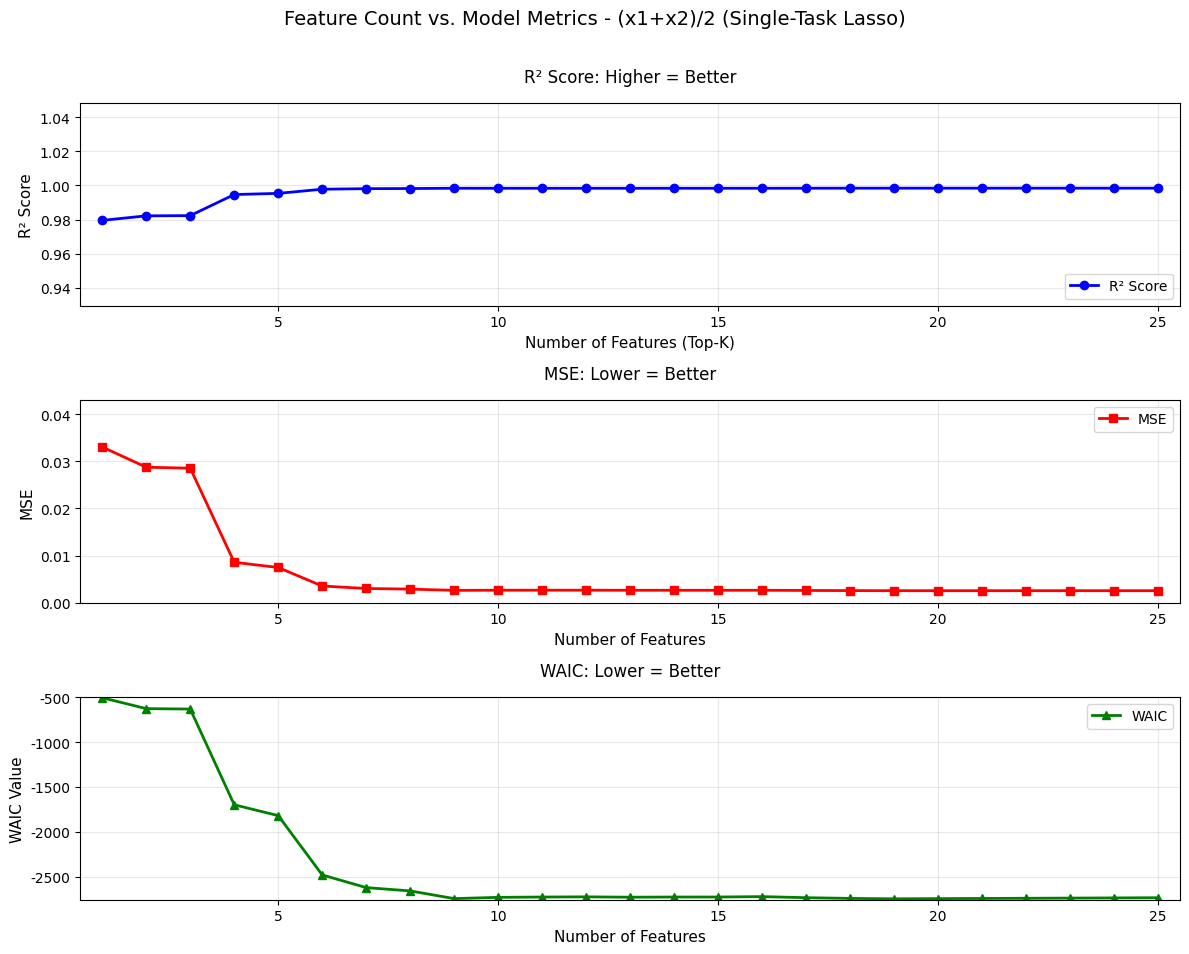

figure has beengenerateand saved as: feature_metrics_task_1.png


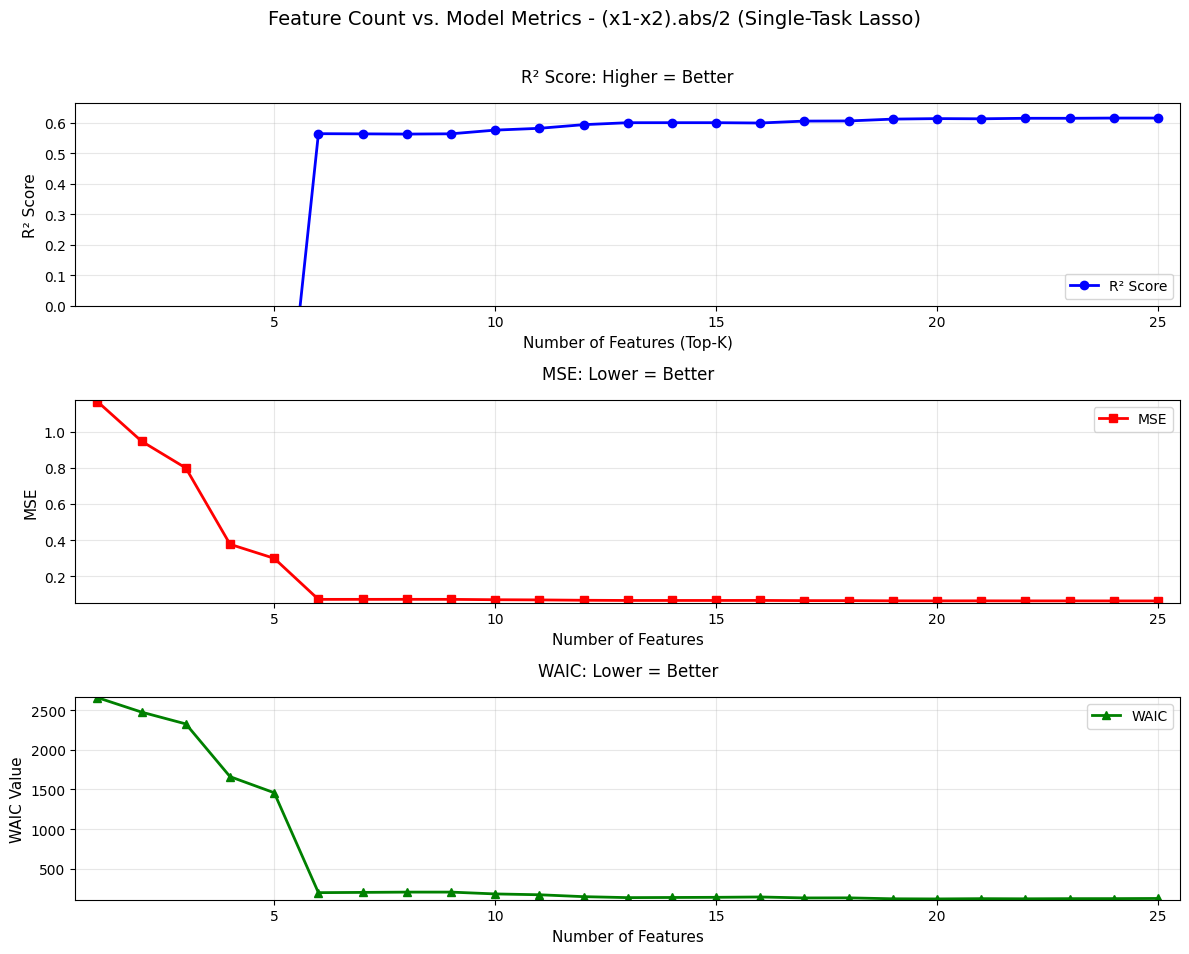

figure has beengenerateand saved as: feature_metrics_task_2.png


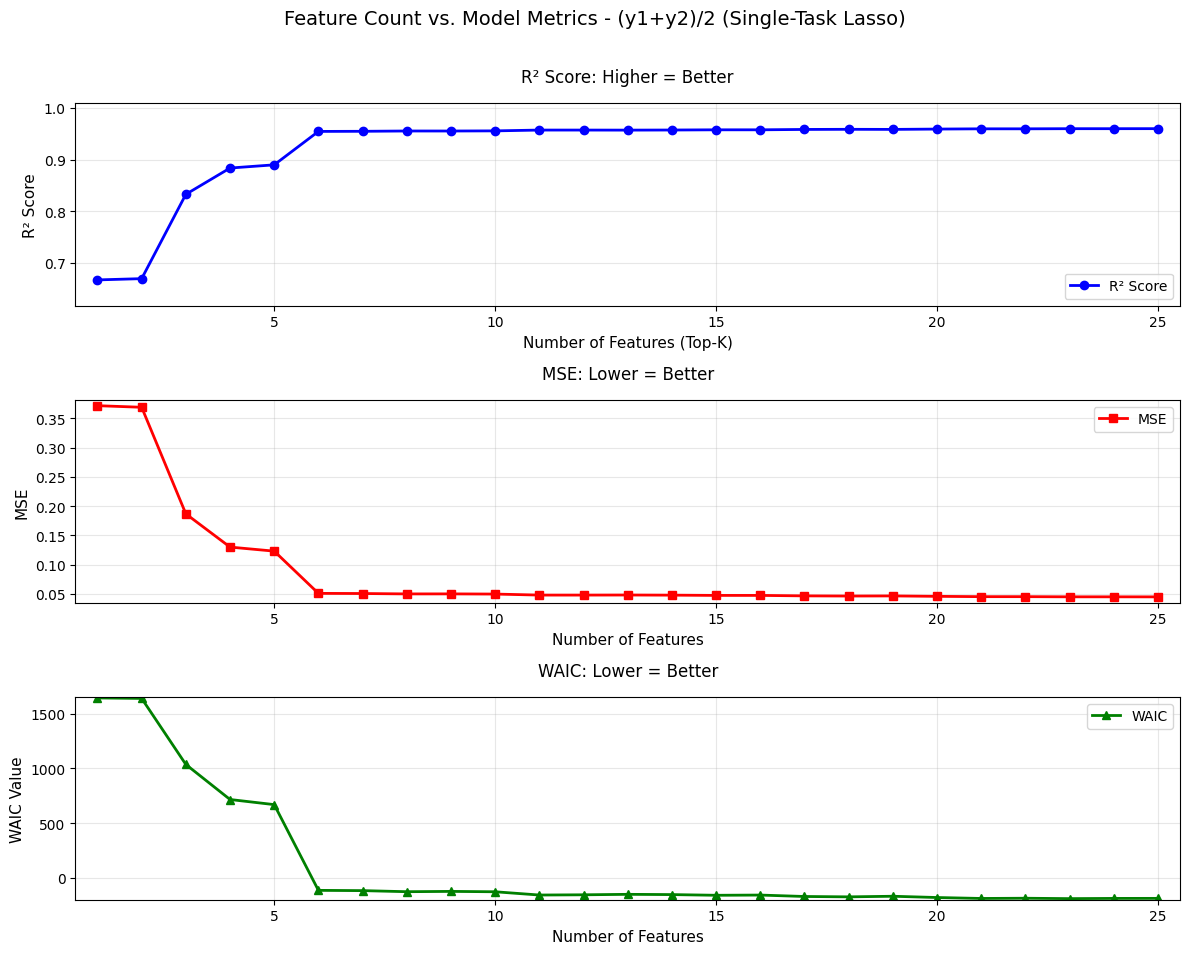

figure has beengenerateand saved as: feature_metrics_task_3.png


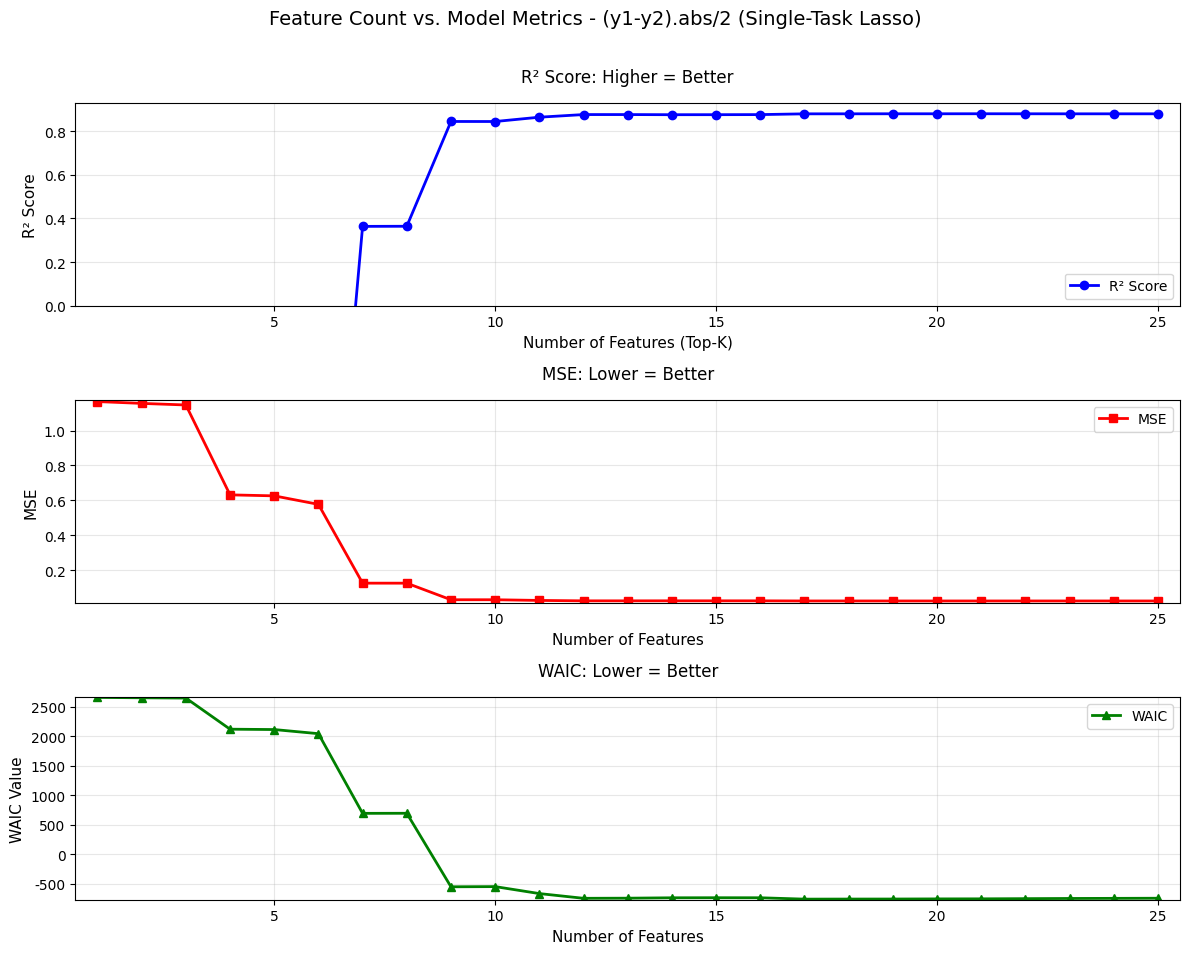

figure has beengenerateand saved as: feature_metrics_task_4.png


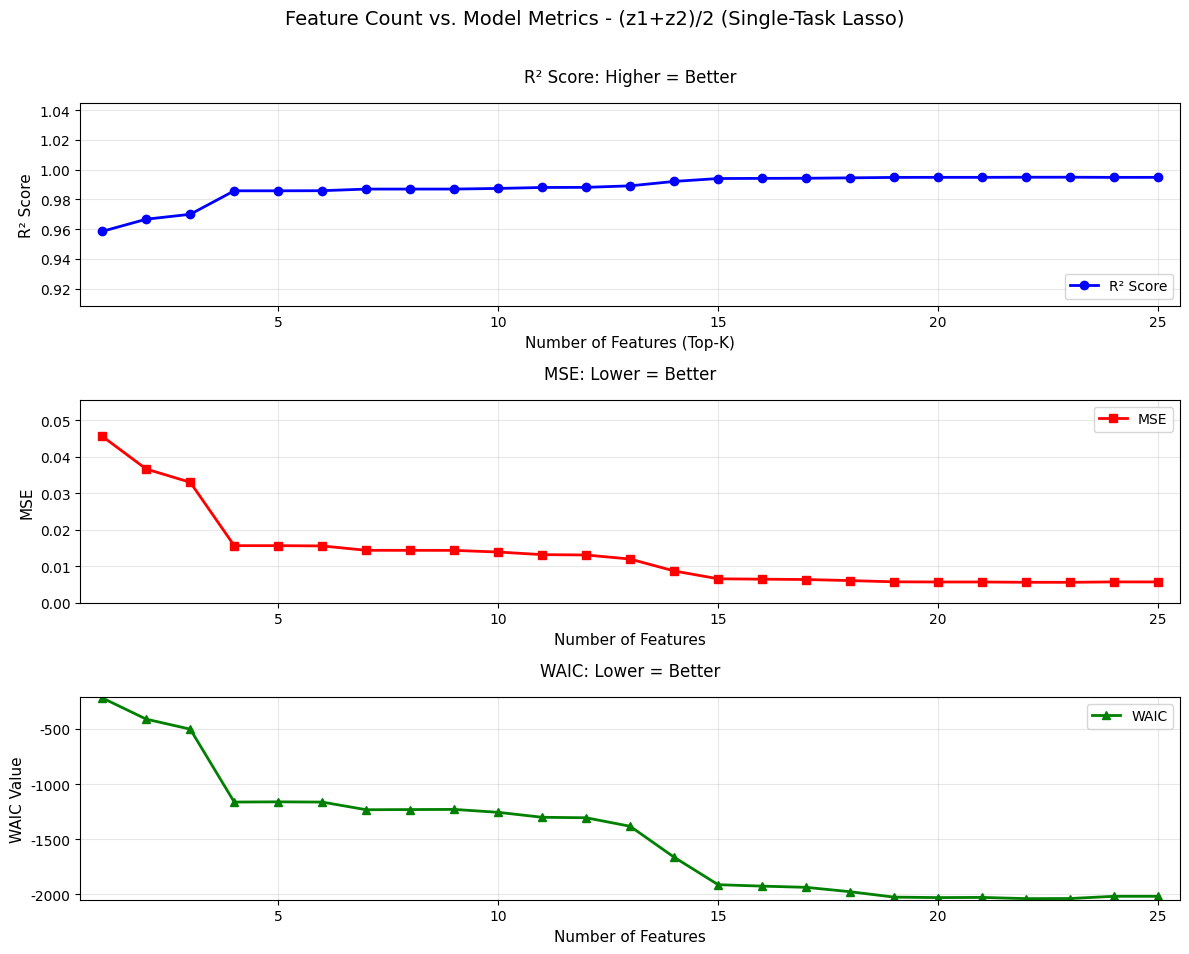

figure has beengenerateand saved as: feature_metrics_task_5.png


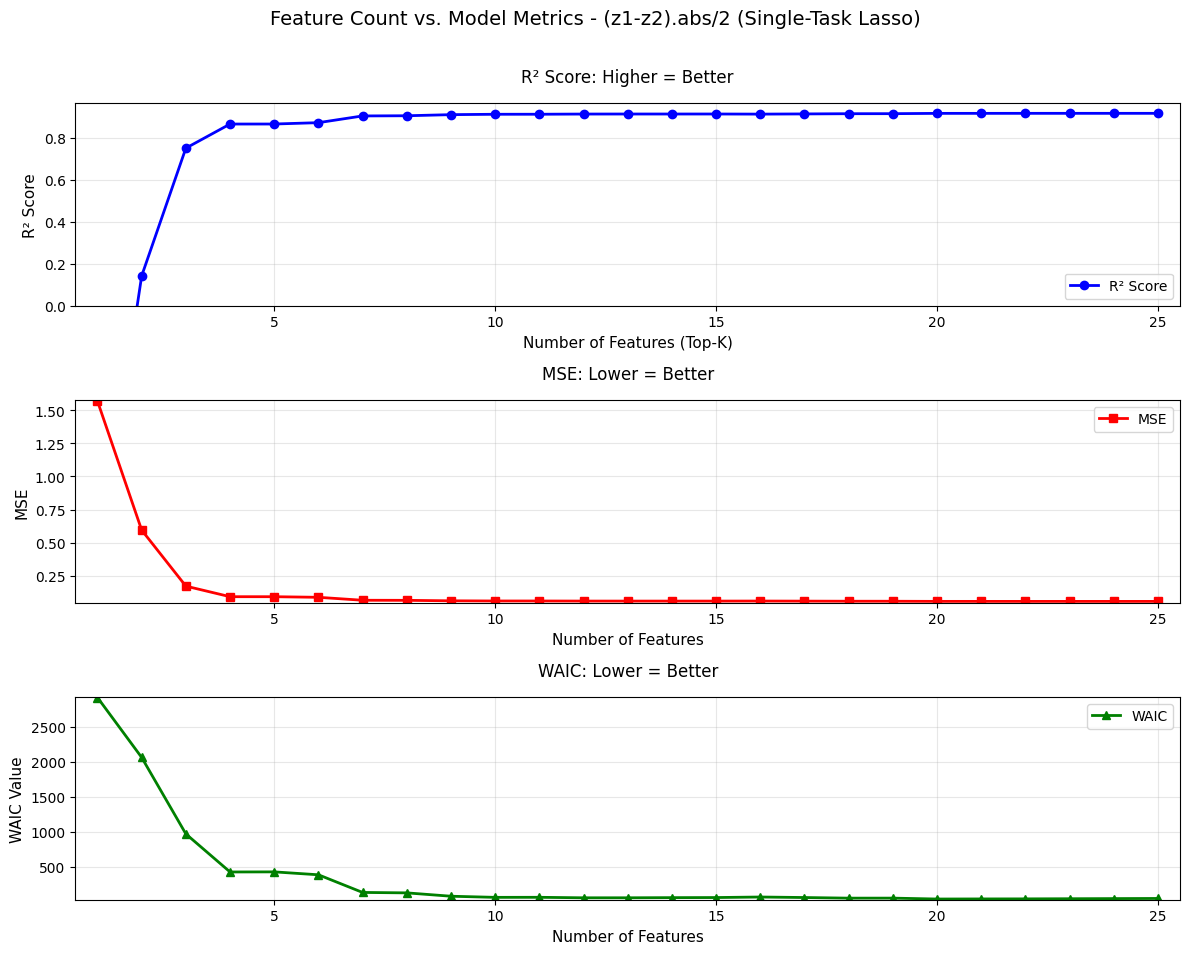

figure has beengenerateand saved as: feature_metrics_task_6.png

all figures andCSVfiles generated！
CSVfile save path: ./dl4
CSVformat description：
column 1：feature name（multiple features separated by commas）
column 2：feature count（1~25）
column 3：R²score
column 4：MSE
column 5：WAIC


In [21]:
# ----------------------
# 4. plotting function（change AIC-related labels to WAIC）
# ----------------------
def plot_feature_metrics_single_task(Score_list, MSE_list, WAIC_list, imp_coef_list, target_names=None):  # change5：AIC_list → WAIC_list
    Score_list = np.asarray(Score_list)
    MSE_list = np.asarray(MSE_list)
    WAIC_list = np.asarray(WAIC_list)  # change6：AIC_list → WAIC_list
    
    n_feature_exp = Score_list.shape[0]
    n_targets = Score_list.shape[1]
    Index = np.arange(1, n_feature_exp + 1)
    
    if target_names is None:
        target_names = [f'Target_{i+1}' for i in range(n_targets)]
    else:
        assert len(target_names) == n_targets, "number of target names does not match"
    
    for task_idx in range(n_targets):
        colors = ['blue', 'red', 'green']
        markers = ['o', 's', '^']
        
        plt.rcParams['font.sans-serif'] = ['Arial', 'SimHei']
        plt.rcParams['axes.unicode_minus'] = False
        fig = plt.figure(figsize=(12, 10))
        fig.suptitle(f'Feature Count vs. Model Metrics - {target_names[task_idx]} (Single-Task Lasso)', 
                    fontsize=14, y=0.95)
        
        ax1 = fig.add_subplot(3, 1, 1)
        ax1.plot(
            Index, Score_list[:, task_idx],
            marker=markers[0], linestyle='-', color=colors[0],
            linewidth=2, markersize=6, label='R² Score'
        )
        ax1.set_xlabel('Number of Features (Top-K)', fontsize=11)
        ax1.set_ylabel('R² Score', fontsize=11)
        ax1.set_xlim(0.5, n_feature_exp + 0.5)
        ax1.set_ylim(max(0, np.min(Score_list[:, task_idx]) - 0.05), 
                     min(1.05, np.max(Score_list[:, task_idx]) + 0.05))
        ax1.legend(loc='lower right', fontsize=10)
        ax1.grid(alpha=0.3)
        ax1.set_title(f'R² Score: Higher = Better', fontsize=12, pad=15)
        
        ax2 = fig.add_subplot(3, 1, 2)
        ax2.plot(
            Index, MSE_list[:, task_idx],
            marker=markers[1], linestyle='-', color=colors[1],
            linewidth=2, markersize=6, label='MSE'
        )
        ax2.set_xlabel('Number of Features', fontsize=11)
        ax2.set_ylabel('MSE', fontsize=11)
        ax2.set_xlim(0.5, n_feature_exp + 0.5)
        ax2.set_ylim(max(0, np.min(MSE_list[:, task_idx]) - 0.01), 
                     np.max(MSE_list[:, task_idx]) + 0.01)
        ax2.legend(loc='upper right', fontsize=10)
        ax2.grid(alpha=0.3)
        ax2.set_title('MSE: Lower = Better', fontsize=12, pad=15)
        
        ax3 = fig.add_subplot(3, 1, 3)
        ax3.plot(
            Index, WAIC_list[:, task_idx],  # change7：AIC_list → WAIC_list
            marker=markers[2], linestyle='-', color=colors[2],
            linewidth=2, markersize=6, label='WAIC'  # change8：AIC → WAIC
        )
        ax3.set_xlabel('Number of Features', fontsize=11)
        ax3.set_ylabel('WAIC Value', fontsize=11)  # change9：AIC Value → WAIC Value
        ax3.set_xlim(0.5, n_feature_exp + 0.5)
        ax3.set_ylim(np.min(WAIC_list[:, task_idx]) - 10,  # change10：AIC_list → WAIC_list
                     np.max(WAIC_list[:, task_idx]) + 10)  # change11：AIC_list → WAIC_list
        ax3.legend(loc='upper right', fontsize=10)
        ax3.grid(alpha=0.3)
        ax3.set_title('WAIC: Lower = Better', fontsize=12, pad=15)  # change12：AIC → WAIC
        
        plt.tight_layout(rect=[0, 0, 1, 0.94])
        plt.savefig(f'feature_metrics_task_{task_idx+1}.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"figure has beengenerateand saved as: feature_metrics_task_{task_idx+1}.png")

# ----------------------
# call plotting function
# ----------------------
plot_feature_metrics_single_task(
    Score_list=Score_list,
    MSE_list=MSE_list,
    WAIC_list=WAIC_list,  # change13：AIC_list → WAIC_list
    imp_coef_list=imp_coef_list,
    target_names=target_names
)

print("\nall figures andCSVfiles generated！")
print(f"CSVfile save path: {save_dir}")
print("CSVformat description：")
print("column 1：feature name（multiple features separated by commas）")
print("column 2：feature count（1~25）")
print("column 3：R²score")
print("column 4：MSE")
print("column 5：WAIC")

start processing coefficients and selecting features...

start computing model metrics (R2, MSE, WAIC)...
metrics for all target columns completed！

start generating figures（including WAIC）...


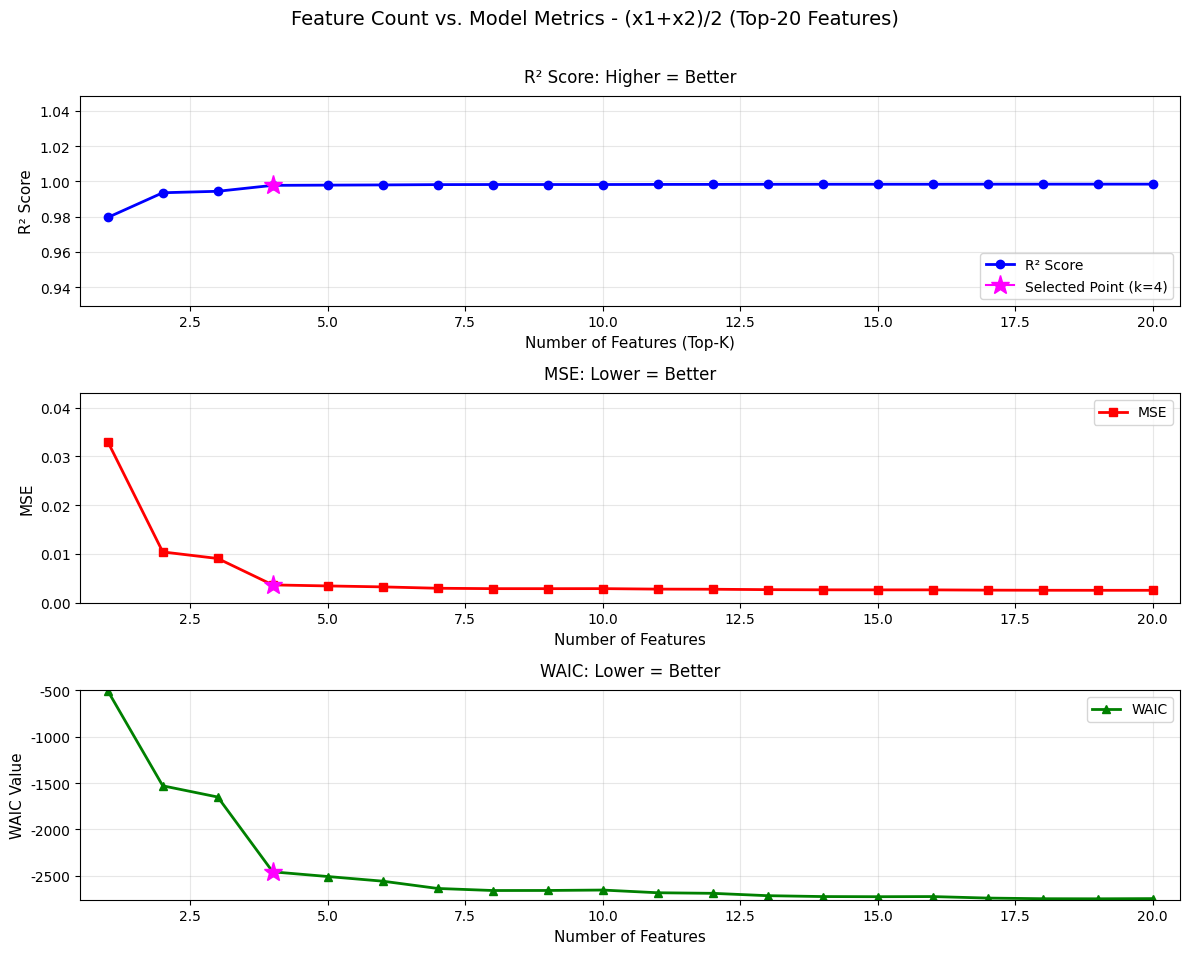

No. 1 target-column chart saved：feature_metrics_task_1_with_WAIC_starred.png


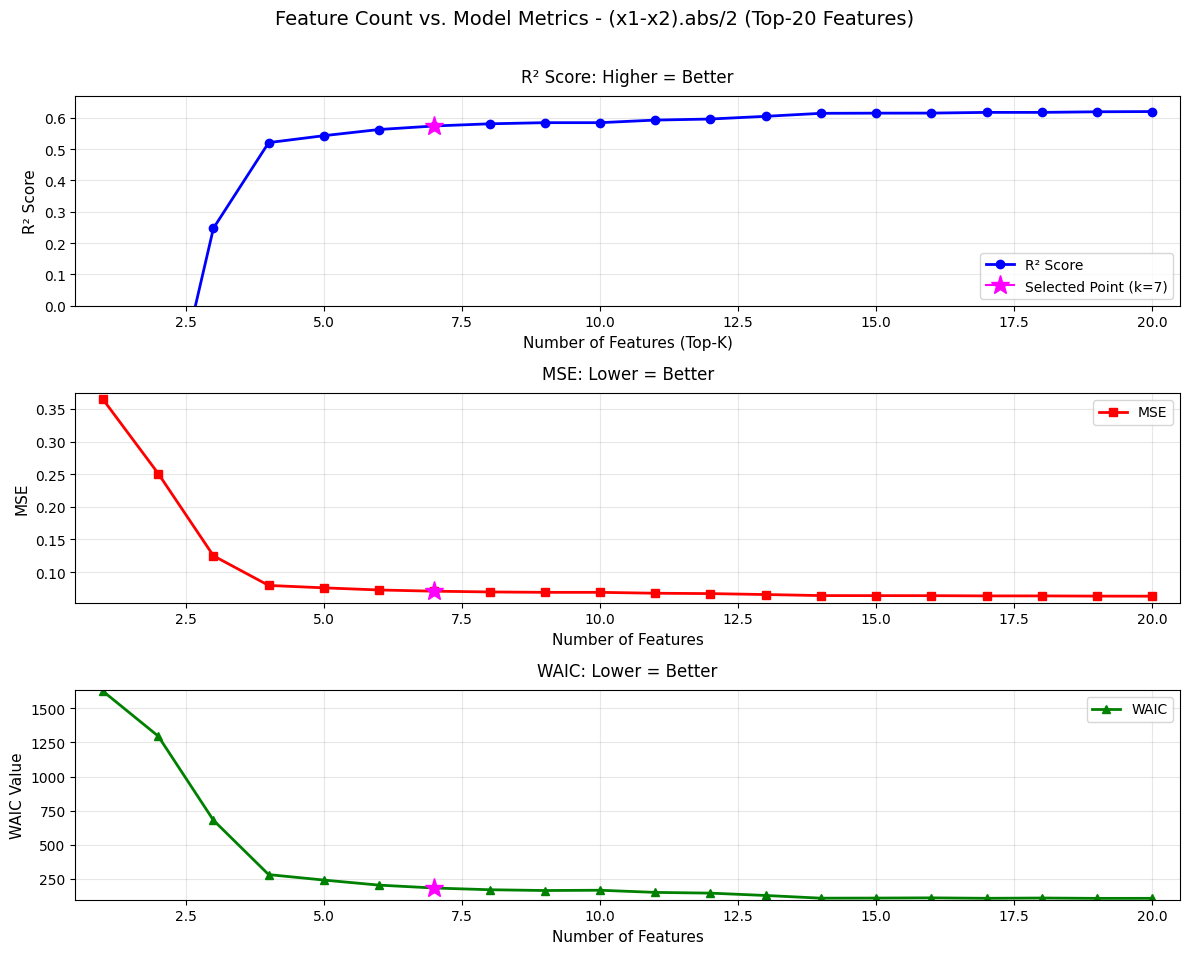

No. 2 target-column chart saved：feature_metrics_task_2_with_WAIC_starred.png


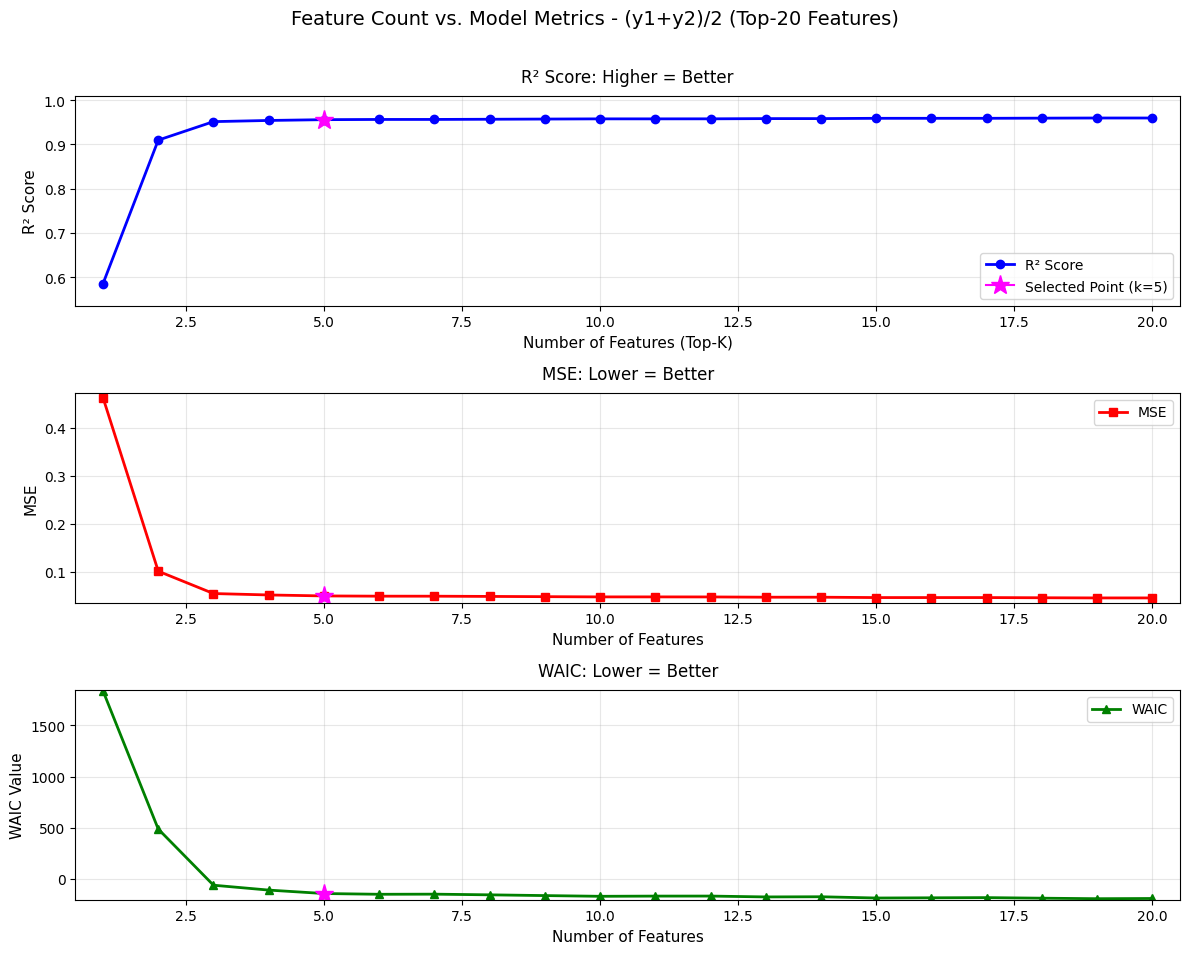

No. 3 target-column chart saved：feature_metrics_task_3_with_WAIC_starred.png


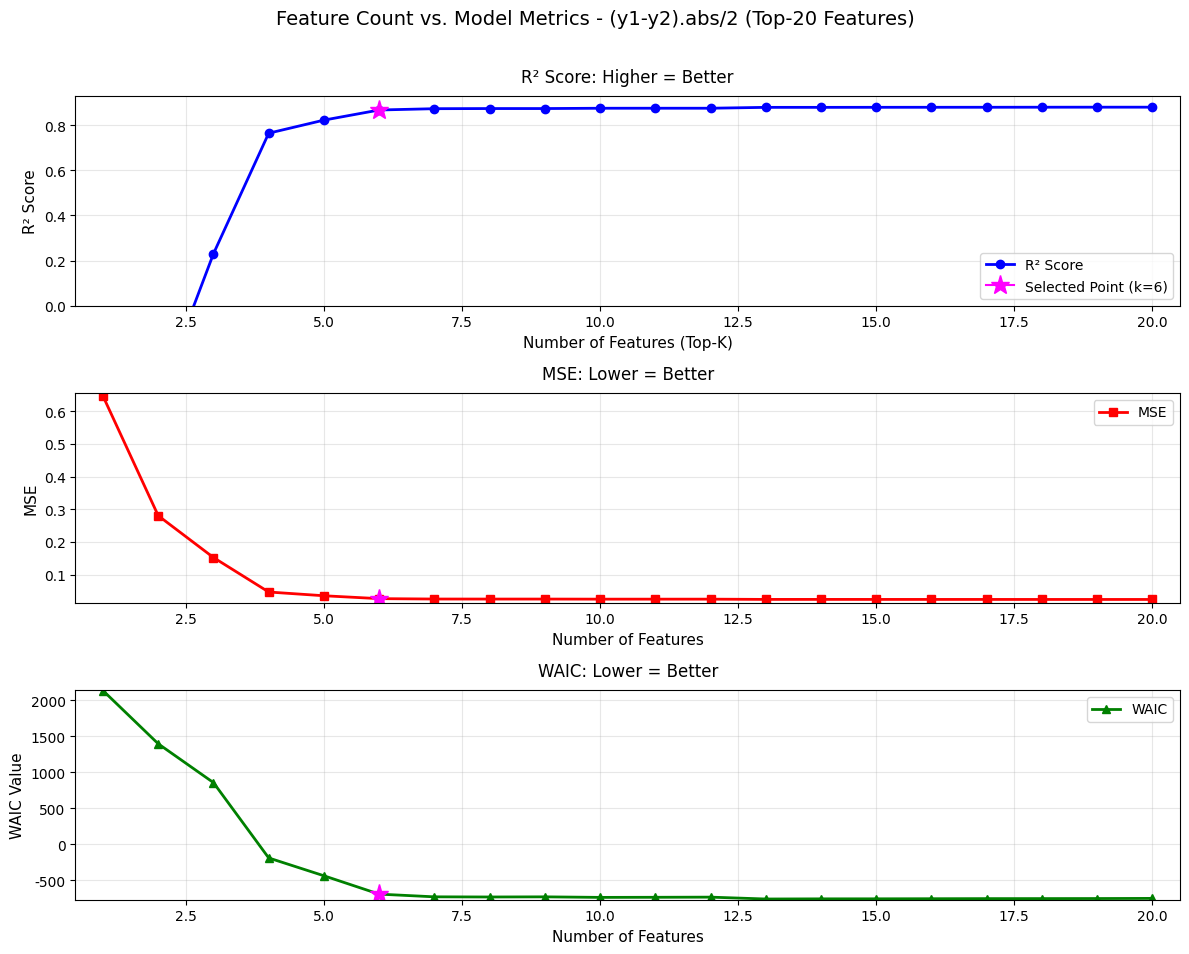

No. 4 target-column chart saved：feature_metrics_task_4_with_WAIC_starred.png


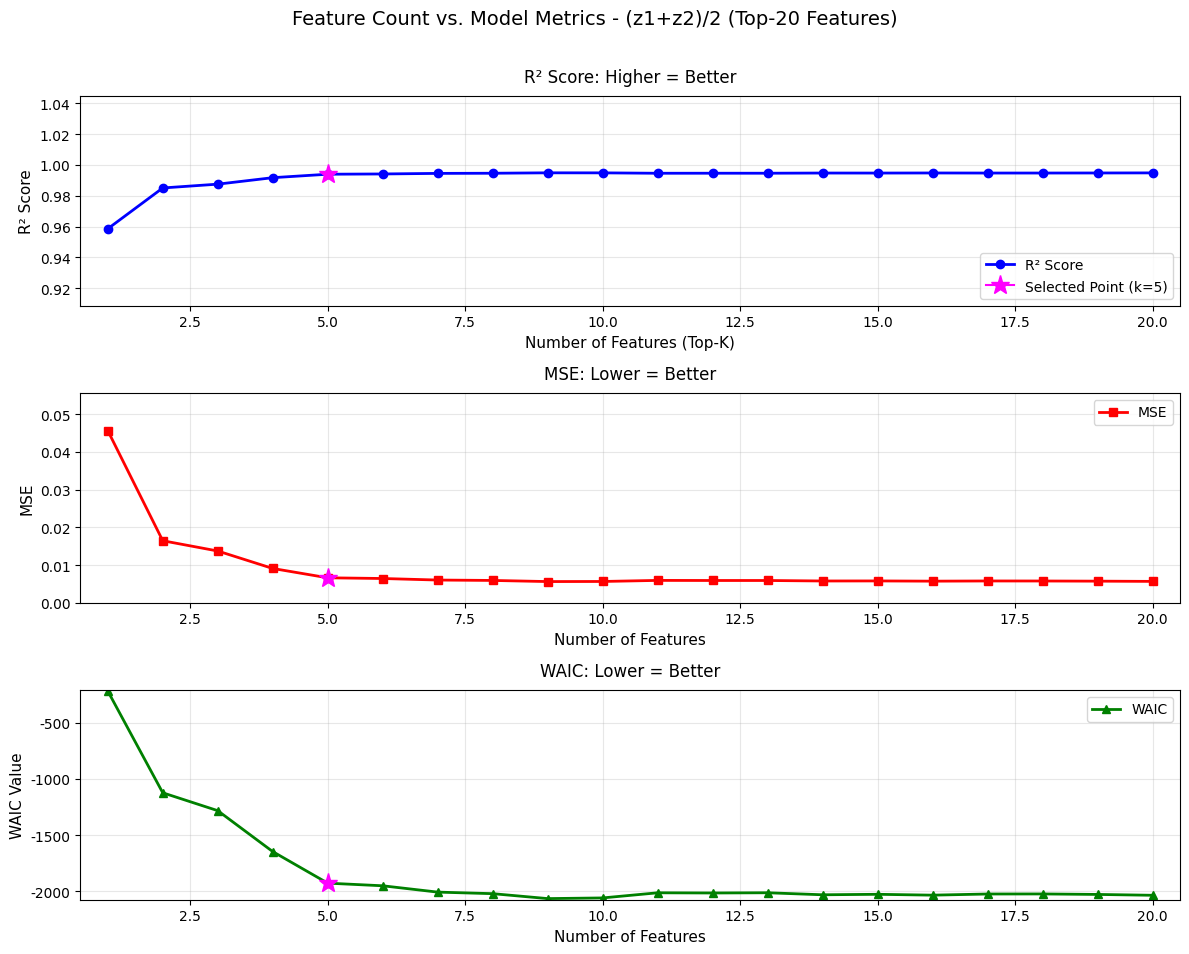

No. 5 target-column chart saved：feature_metrics_task_5_with_WAIC_starred.png


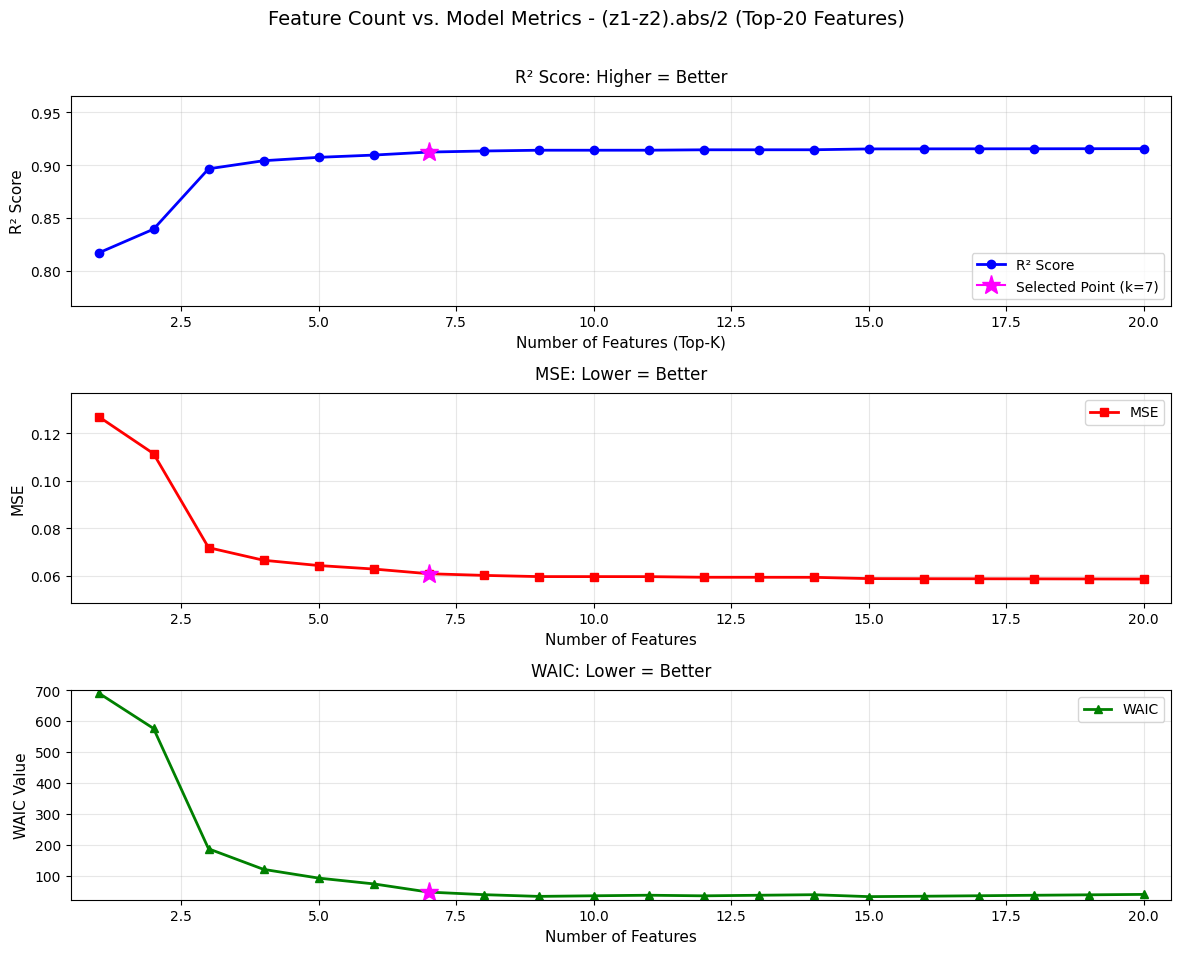

No. 6 target-column chart saved：feature_metrics_task_6_with_WAIC_starred.png
including WAIC summary table saved：final_feature_summary_with_WAIC.csv

save the completeWAICmetrics...
  No. 1 target-column complete metrics saved：task_1_full_metrics_with_WAIC.csv
  No. 2 target-column complete metrics saved：task_2_full_metrics_with_WAIC.csv
  No. 3 target-column complete metrics saved：task_3_full_metrics_with_WAIC.csv
  No. 4 target-column complete metrics saved：task_4_full_metrics_with_WAIC.csv
  No. 5 target-column complete metrics saved：task_5_full_metrics_with_WAIC.csv
  No. 6 target-column complete metrics saved：task_6_full_metrics_with_WAIC.csv

all tasks completed！highlight points correspond tokvalue：[4, 7, 5, 6, 5, 7]
output file description：
1. feature_metrics_task_*_with_WAIC_starred.png：packageincludingR²/MSE/WAIC visualization chart（with highlighted points）
2. final_feature_summary_with_WAIC.csv：summary table（including selected/not-selected featureWAICmetrics）
3. task_*_full_me

In [43]:
# ----------------------
# 1. coefficientprocessand importantfeatureselect（changed to Top 20，remove the last 20）
# ----------------------
print("start processing coefficients and selecting features...")
# compute each X-column absolute-sum before normalization（used for coefficient denormalization）
x_norml1 = [np.sum(np.abs(X[col].values)) for col in X.columns]
X_col = X.columns.tolist()

# coefficient denormalization（process each target column independently）
# adjusted_coef_list willsaveoriginalfeaturenamecorresponding toofdenormalized coefficientsSeries
adjusted_coef_list = []
for task_idx in range(6):  # iterate over six target columns
    current_coef = []
    coef_values = models[task_idx].coef_  # Lasso coefficients for the current target column

    for feat_idx, feat_name in enumerate(X_col):
        # denormalization formula：coefficient * (ycolumn original absolute-sum / Xcolumn original absolute-sum)
        if x_norml1[feat_idx] != 0:
            scale_factor = y_abs_sum_before[task_idx] / x_norml1[feat_idx]
        else:
            scale_factor = 1  # avoid division by zero
        adjusted_coef = coef_values[feat_idx] * scale_factor
        current_coef.append(adjusted_coef)

    # convert to Series，for later sorting/selection and final table indexing
    coef_series = pd.Series(current_coef, index=X_col, name=f'y_col_{task_idx+1}')
    adjusted_coef_list.append(coef_series)

# select Top-20 important features for each target column（sort by coefficient absolute value，remove the last 20）
imp_coef_list = []
for i in range(6):
    # sort by coefficient absolute value in descending order，take the first 20 features（remove the last 20）
    # a tiny amount is added here for sorting stability，use the actual values from adjusted_coef_list
    top20_coef_sorted = adjusted_coef_list[i].abs().sort_values(ascending=False).head(20)
    imp_coef_list.append(top20_coef_sorted) # absolute values are stored here，mainly used to obtain the index

# ----------------------
# 2. generate independent 20 candidate features for each target column（use Top 20 directly，no further truncation needed）
# ----------------------
k_range = range(1, 21)  # test 1~20features（original 41 changed to 21）
n_samples = X.shape[0]

# initialize result arrays（metrics stored independently for each target column，dimensions changed consistently to20×6）
Score_list = np.zeros((len(k_range), 6))  # R²score
MSE_list = np.zeros((len(k_range), 6))    # mean squared error
WAIC_list = np.zeros((len(k_range), 6))   # WAICvalue (replace original AIC_list，keep the computation logic)

# define an independent manually adjusted order for each target column（1-20permutation，remove originallastside20 items）
# format：key=target column index（0-5），value=1-20ofcustom order list（keep original first 20 items，delete the last 20）
manual_indices_per_task = {
    0: [1,2,3,4,6,5,7,12,11,8,9,10,13,14,15,16,17,18,19,20],  # column 1（keep original first 20）
    1: [1,2,3,5,16,6,4,7,8,9,10,11,12,13,14,15,17,18,19,20],  # column 2（keep original first 20）
    2: [1,3,2,4,8,6,5,9,10,7,11,12,13,14,15,16,17,18,19,20],  # column 3（keep original first 20）
    3: [1,4,9,3,8,2,7,5,6,10,11,12,13,14,15,16,17,18,19,20],  # column 4（keep original first 20）
    4: [1,4,3,5,9,2,14,15,6,7,8,10,11,12,13,16,17,18,19,20],  # column 5（keep original first 20）
    5: [1,2,4,5,3,6,8,7,9,10,11,12,13,14,15,16,17,18,19,20]    # No. 6column（keep original first 20）
}

# validate the manual order（must contain all numbers from 1 to 20，no duplicates，length 20）
for task_idx in range(6):
    indices = manual_indices_per_task[task_idx]
    if set(indices) != set(range(1, 21)) or len(indices) != 20:
        raise ValueError(f"No. {task_idx+1}target columnofmanual index error：must contain all numbers from 1 to 20，without duplicates！")

# generate the final feature order for each target column（Top20 + manual adjustment，remove the last 20）
final_feature_orders = []
for task_idx in range(6):
    # directly obtain Top-20 features of the current target column（length exactly 20，no extra items）
    candidate_features = imp_coef_list[task_idx].index.tolist()

    # edge case：if Top 20 has fewer than 20 items（e.g., original feature count<20），pad with remaining features
    if len(candidate_features) < 20:
        remaining_feats = [f for f in X_col if f not in candidate_features]
        candidate_features += remaining_feats[:20 - len(candidate_features)]

    # apply manually adjusted order（convert the 1-20 order to indices 0-19）
    adjusted_indices = [i - 1 for i in manual_indices_per_task[task_idx]]
    final_order = [candidate_features[i] for i in adjusted_indices]
    final_feature_orders.append(final_order)

# ----------------------
# 3. computeeach target columnofmodelmetrics（usecustomfeature order，mostmultiple20features）
# ----------------------
print("\nstart computing model metrics (R2, MSE, WAIC)...")
# convert y_norm uniformly to a NumPy array（compatible with DataFrame or array input）
if isinstance(y_norm, pd.DataFrame):
    y_norm_array = y_norm.values
else:
    y_norm_array = y_norm

# iterate over each target column，compute metrics for different feature counts（1-20 items）
for task_idx in range(6):
    current_feature_order = final_feature_orders[task_idx]  # whenfirsttarget columnoffeature order（20 items）

    for k_idx, k in enumerate(k_range):
        # takefirstkfeatures（according to custom order，kmaximum 20）
        selected_features = current_feature_order[:k]
        X_k = X[selected_features].values  # feature subset

        # take label data for the current target column
        if y_norm_array.ndim == 2 and y_norm_array.shape[1] > 1:
            y_task = y_norm_array[:, task_idx]
        else:
            y_task = y_norm_array  # edge case：ify_normis1Dnumbergroup（only one target column，but this scenario has six columns）

        # check whether sample counts match（avoid training errors）
        if X_k.shape[0] != len(y_task):
            print(f"  Warning: No. {task_idx+1}target column（k={k}）number of samplesmismatch！X_k:{X_k.shape[0]}, y_task:{len(y_task)}")
            continue

        # train Lasso model and compute metrics（catch exceptions with try-except，avoid interrupting the program）
        try:
            reg_k = LassoCV(
                cv=5, fit_intercept=False, n_jobs=-1, max_iter=10000, normalize=False
            ).fit(X_k, y_task)

            # prediction and metric computation
            y_pred = reg_k.predict(X_k)
            Score_list[k_idx, task_idx] = r2_score(y_task, y_pred)  # R²
            MSE = mean_squared_error(y_task, y_pred)  # MSE
            MSE_list[k_idx, task_idx] = MSE
            
            # WAIC computation（replace originalAICcompute，simplified WAIC adapted for regression models）
            # WAICformula：WAIC = -2 * (lppd - p_waic)
            # lppd: log pointwise predictive density；p_waic: number of effective parameters（simplified as feature count k，aligned with the original AIC logic）
            log_likelihood = -0.5 * (np.log(2 * np.pi * MSE) + (y_task - y_pred)**2 / MSE)
            lppd = np.sum(log_likelihood)
            p_waic = k  # simplified versionnumber of effective parameters（can also be changed to k+1，with originalAICofk+1to stay consistent）
            WAIC = -2 * (lppd - p_waic)
            WAIC_list[k_idx, task_idx] = WAIC

        except Exception as e:
            print(f"  Error: No. {task_idx+1}target column（k={k}）training failed：{str(e)[:50]}...")
            # fill default values on exception，avoid later errors
            Score_list[k_idx, task_idx] = np.nan
            MSE_list[k_idx, task_idx] = np.nan
            WAIC_list[k_idx, task_idx] = np.nan

# handle NaN values（replace with reasonable defaults）
Score_list = np.nan_to_num(Score_list, nan=0)  # R²fill exception with 0
MSE_list = np.nan_to_num(MSE_list, nan=1)      # MSEfill exception with 1
WAIC_list = np.nan_to_num(WAIC_list, nan=1000) # WAICfill exception with 1000

print("metrics for all target columns completed！")

# ----------------------
# 4. plotting function（change：restore WAIC subplot，keep highlighted points）
# ----------------------
# define points to highlight xi (x=[4 5 3 6 5 5])，corresponding to six groups of data
highlight_ks = [4, 7, 5, 6, 5, 7]

def plot_feature_metrics_with_WAIC(Score_list, MSE_list, WAIC_list, highlight_ks, target_names=None):
    # convert to NumPy array（ensure consistent format）
    Score_list = np.asarray(Score_list)
    MSE_list = np.asarray(MSE_list)
    WAIC_list = np.asarray(WAIC_list)

    # basic parameters（feature count changed to 1-20）
    n_feature_exp = Score_list.shape[0]  # feature count（1-20）
    n_targets = Score_list.shape[1]      # number of target columns（6）
    Index = np.arange(1, n_feature_exp + 1)  # xaxis coordinates（1-20）

    # target column name（default or custom）
    if target_names is None:
        target_names = [f'Target_{i+1}' for i in range(n_targets)]
    else:
        assert len(target_names) == n_targets, "number of target names must match number of target columns！"

    for task_idx in range(n_targets):
        k_highlight = highlight_ks[task_idx]
        idx_highlight = k_highlight - 1 


        colors = ['blue', 'red', 'green'] 
        markers = ['o', 's', '^']         
        highlight_color = 'magenta'       
        highlight_marker = '*'            

        plt.rcParams['font.sans-serif'] = ['Arial', 'SimHei']
        plt.rcParams['axes.unicode_minus'] = False
        fig = plt.figure(figsize=(12, 10))
        fig.suptitle(
            f'Feature Count vs. Model Metrics - {target_names[task_idx]} (Top-20 Features)',
            fontsize=14, y=0.95
        )

        # subplot 1：R²score
        ax1 = fig.add_subplot(3, 1, 1)
        ax1.plot(
            Index, Score_list[:, task_idx],
            marker=markers[0], linestyle='-', color=colors[0],
            linewidth=2, markersize=6, label='R² Score'
        )
        ax1.plot(Index[idx_highlight], Score_list[idx_highlight, task_idx],
                 marker=highlight_marker, color=highlight_color,
                 markersize=14, label=f'Selected Point (k={k_highlight})')

        ax1.set_xlabel('Number of Features (Top-K)', fontsize=11)
        ax1.set_ylabel('R² Score', fontsize=11)
        ax1.set_xlim(0.5, n_feature_exp + 0.5) 
        ax1.set_ylim(max(0, np.min(Score_list[:, task_idx]) - 0.05), min(1.05, np.max(Score_list[:, task_idx]) + 0.05))
        ax1.legend(loc='lower right', fontsize=10)
        ax1.grid(alpha=0.3)
        ax1.set_title('R² Score: Higher = Better', fontsize=12, pad=10)

        # subplot 2：MSE
        ax2 = fig.add_subplot(3, 1, 2)
        ax2.plot(
            Index, MSE_list[:, task_idx],
            marker=markers[1], linestyle='-', color=colors[1],
            linewidth=2, markersize=6, label='MSE'
        )
        ax2.plot(Index[idx_highlight], MSE_list[idx_highlight, task_idx],
                 marker=highlight_marker, color=highlight_color,
                 markersize=14)

        ax2.set_xlabel('Number of Features', fontsize=11)
        ax2.set_ylabel('MSE', fontsize=11)
        ax2.set_xlim(0.5, n_feature_exp + 0.5)  
        ax2.set_ylim(max(0, np.min(MSE_list[:, task_idx]) - 0.01), np.max(MSE_list[:, task_idx]) + 0.01)
        ax2.legend(loc='upper right', fontsize=10)
        ax2.grid(alpha=0.3)
        ax2.set_title('MSE: Lower = Better', fontsize=12, pad=10)

        # subplot 3：WAIC
        ax3 = fig.add_subplot(3, 1, 3)
        ax3.plot(
            Index, WAIC_list[:, task_idx],
            marker=markers[2], linestyle='-', color=colors[2],
            linewidth=2, markersize=6, label='WAIC'
        )
        ax3.plot(Index[idx_highlight], WAIC_list[idx_highlight, task_idx],
                 marker=highlight_marker, color=highlight_color,
                 markersize=14)

        ax3.set_xlabel('Number of Features', fontsize=11)
        ax3.set_ylabel('WAIC Value', fontsize=11)
        ax3.set_xlim(0.5, n_feature_exp + 0.5) 
        ax3.set_ylim(np.min(WAIC_list[:, task_idx]) - 10, np.max(WAIC_list[:, task_idx]) + 10)
        ax3.legend(loc='upper right', fontsize=10)
        ax3.grid(alpha=0.3)
        ax3.set_title('WAIC: Lower = Better', fontsize=12, pad=10)

        plt.tight_layout(rect=[0, 0, 1, 0.94]) 
        save_path = f'feature_metrics_task_{task_idx+1}_with_WAIC_starred.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"No. {task_idx+1} target-column chart saved：{save_path}")

# ----------------------
# 5. call plotting function + generate summary tableCSV
# ----------------------
# target column name
target_names = ['(x1+x2)/2', '(x1-x2).abs/2', '(y1+y2)/2', 
                '(y1-y2).abs/2', '(z1+z2)/2', '(z1-z2).abs/2']

# define final selected feature count for each target column (corresponding to highlight_ks)
# logic：the table will show k selected features + 1  itemsNot Selectedfeature
target_feature_nums = {
    0: highlight_ks[0], # Target 1
    1: highlight_ks[1], # Target 2
    2: highlight_ks[2], # Target 3
    3: highlight_ks[3], # Target 4
    4: highlight_ks[4], # Target 5
    5: highlight_ks[5]  # Target 6
}

print("\nstart generating figures（including WAIC）...")
plot_feature_metrics_with_WAIC(
    Score_list=Score_list, 
    MSE_list=MSE_list, 
    WAIC_list=WAIC_list,  
    highlight_ks=highlight_ks, 
    target_names=target_names
)

summary_data = []

# normalize y_norm format to compute initial values
if isinstance(y_norm, pd.DataFrame):
    y_norm_array = y_norm.values
else:
    y_norm_array = y_norm

for task_idx in range(6):
    t_name = target_names[task_idx]
    full_coef_series = adjusted_coef_list[task_idx] # denormalized coefficients
    ordered_feats = final_feature_orders[task_idx]  # Top 20 order
    
    k_selected = target_feature_nums[task_idx]
    limit = min(len(ordered_feats), k_selected + 1)
    
    # gettakelabel data for the current taskused to compute initial values
    if y_norm_array.ndim == 2 and y_norm_array.shape[1] > 1:
        y_task = y_norm_array[:, task_idx]
    else:
        y_task = y_norm_array

    r2_prev = 0.0
    mse_prev = mean_squared_error(y_task, np.zeros_like(y_task))
    waic_prev = 1000  # initial WAIC value

    # iterate only over the first limit features (i.e. k itemsSelected + 1not-selected feature)
    for i in range(limit):
        feat_name = ordered_feats[i]
        rank = i + 1
        
        # determine status
        if rank <= k_selected:
            status = "Selected"
        else:
            status = "Excluded (Next Candidate)"
        
        # 1. find denormalized coefficients
        coef_val = full_coef_series.loc[feat_name]
        
        # 2. get current step(k=rank) metrics
        r2_curr = Score_list[i, task_idx]
        mse_curr = MSE_list[i, task_idx]
        waic_curr = WAIC_list[i, task_idx]
        
        # 3. compute increase/decrease
        r2_gain = r2_curr - r2_prev
        mse_reduction = mse_prev - mse_curr
        waic_change = waic_prev - waic_curr  # WAIC change（positive value means lower，better）
        
        # 4. store data（newWAICphaseoffcolumn）
        summary_data.append({
            'Target Name': t_name,
            'Rank': rank,
            'Feature Name': feat_name,
            'Selection Status': status,
            'R2': r2_curr,          # new：current R2 value
            'R2_Gain': r2_gain,
            'MSE': mse_curr,        # new：current MSE value
            'MSE_Reduction': mse_reduction,
            'WAIC': waic_curr,      # new：current WAIC value
            'WAIC_Change': waic_change  # new：WAIC change
        })
        
        # update previous state to current state
        r2_prev = r2_curr
        mse_prev = mse_curr
        waic_prev = waic_curr

# create DataFrame and save
summary_df = pd.DataFrame(summary_data)

# adjust column order（improve presentation）
cols = [
    'Target Name', 'Rank', 'Selection Status', 'Feature Name',
    'R2', 'R2_Gain', 'MSE', 'MSE_Reduction', 'WAIC', 'WAIC_Change'
]
summary_df = summary_df[cols]

# save summary CSV
summary_csv_path = 'final_feature_summary_with_WAIC.csv'
summary_df.to_csv(summary_csv_path, index=False, encoding='utf-8-sig')
print(f"including WAIC summary table saved：{summary_csv_path}")

print("\nsave the completeWAICmetrics...")
for task_idx in range(6):
    full_metrics_df = pd.DataFrame({
        'Feature_Count': range(1, 21),
        'R2': Score_list[:, task_idx],
        'MSE': MSE_list[:, task_idx],
        'WAIC': WAIC_list[:, task_idx]
    })
    full_metrics_path = f'task_{task_idx+1}_full_metrics_with_WAIC.csv'
    full_metrics_df.to_csv(full_metrics_path, index=False, encoding='utf-8-sig')
    print(f"  No. {task_idx+1} target-column complete metrics saved：{full_metrics_path}")

print(f"\nall tasks completed！highlight points correspond tokvalue：{highlight_ks}")
print("output file description：")
print("1. feature_metrics_task_*_with_WAIC_starred.png：packageincludingR²/MSE/WAIC visualization chart（with highlighted points）")
print("2. final_feature_summary_with_WAIC.csv：summary table（including selected/not-selected featureWAICmetrics）")
print("3. task_*_full_metrics_with_WAIC.csv：each target column1-20full metric data for features")

In [47]:
print("\n=== start generating feature-order files for the final step ===")

for task_idx in range(6):
    current_final_order = final_feature_orders[task_idx]  
    
    df_order = pd.DataFrame({'feature_name': current_final_order})
    file_name = f'feature_order_task_{task_idx+1}_top20.csv'
    df_order.to_csv(file_name, index=False, encoding='utf-8-sig')

# 2. based on the truncation numbers set in your last code block (4,5,4,6,4,5) apply a hard cutoff，check what the final features actually are
k_cutoffs = {0: 4, 1: 7, 2: 5, 3: 6, 4: 5, 5: 7}
t_names = ['(x1+x2)/2', '(x1-x2).abs/2', '(y1+y2)/2', '(y1-y2).abs/2', '(z1+z2)/2', '(z1-z2).abs/2']

final_summary_dict = {}
for task_idx in range(6):
    k = k_cutoffs[task_idx]
    final_selected_feats = final_feature_orders[task_idx][:k]
    col_name = f"Target_{task_idx+1}_{t_names[task_idx]}"
    final_summary_dict[col_name] = final_selected_feats



=== start generating feature-order files for the final step ===


In [48]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def format_linear_equation(features, coefs, target_name, decimal=4):
    """generate a linear regression equation string（without intercept）"""
    rounded_coefs = np.round(coefs, decimal)
    terms = []
    for i, (feat, coef) in enumerate(zip(features, rounded_coefs)):
        if coef == 0:
            continue
        if i == 0:
            term = f"{coef}×{feat}"
        else:
            if coef > 0:
                term = f" + {coef}×{feat}"
            else:
                term = f" - {abs(coef)}×{feat}"
        terms.append(term)
    if not terms:
        return f"{target_name} = 0"
    return f"{target_name} = " + "".join(terms)

def format_equation_with_std(features, means, stds, target_name, decimal=4):
    """generate a linear regression equation string containing coefficient means±standard deviations（without intercept）"""
    rounded_means = np.round(means, decimal)
    rounded_stds = np.round(stds, decimal)
    terms = []
    for i, (feat, mean, std) in enumerate(zip(features, rounded_means, rounded_stds)):
        if mean == 0 and std == 0:
            continue
        if mean >= 0:
            coef_str = f"({mean}±{std})"
        else:
            abs_mean = abs(mean)
            coef_str = f"({abs_mean}±{std})"
        if i == 0:
            term = f"{coef_str}×{feat}" if mean >= 0 else f"-{coef_str}×{feat}"
        else:
            if mean > 0:
                term = f" + {coef_str}×{feat}"
            elif mean < 0:
                term = f" - {coef_str}×{feat}"
            else:
                continue
        terms.append(term)
    if not terms:
        return f"{target_name} = 0"
    return f"{target_name} = " + "".join(terms)

# ===================== fixed parameters =====================
RANDOM_SEED = 42
NUM_RANDOM_GROUPS = 100
TRAIN_SIZE = 400

# ===================== 🔥 fix1：correct feature counts（target column3from5→6，solve missing one feature） =====================
target_feature_nums = {
    0: 4,  # target1
    1: 7,  # target2
    2: 5,  # target3 (y1+y2)/2 → originally5，changed to6
    3: 6,  # target4
    4: 5,  # target5
    5: 7   # target6
}

np.random.seed(RANDOM_SEED)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 10

# your original data（please ensure X1 / result_6cols has been defined correctly）
X_original = X1.copy().reset_index(drop=True)
y_original = result_6cols.copy().reset_index(drop=True)
total_samples = len(X_original)

# target column name
target_names = [
    '(x1+x2)/2', 
    '(x1-x2).abs/2', 
    '(y1+y2)/2',
    '(y1-y2).abs/2', 
    '(z1+z2)/2', 
    '(z1-z2).abs/2'
]

# ===================== 🔥 fix2：remove duplicate code，load only【once】feature =====================
print("determining final features for each target column（directly use Top K）...")
target_features = {}
for task_idx in range(6):
    feature_file = f'feature_order_task_{task_idx+1}_top20.csv'
    target_name = target_names[task_idx]
    num_feats = target_feature_nums[task_idx]

    if os.path.exists(feature_file):
        feature_df = pd.read_csv(feature_file)
        selected_feats = feature_df['feature_name'].tolist()[:num_feats]
        target_features[task_idx] = selected_feats
        print(f"✅ target column{task_idx+1}({target_name}) - number of selected features: {len(selected_feats)}")
        print(f"   feature list: {selected_feats}")
    else:
        raise FileNotFoundError(f"feature-order file not found: {feature_file}")

# -------------------------- computeall888 itemssamplesofbaselineR2 --------------------------
print("="*80)
print("📊 R2 results for each target column on all 888 samples（baseline value）")
print("="*80)

full_data_r2_results = []
for target_idx in range(6):
    current_features = target_features[target_idx]
    current_target_name = target_names[target_idx]
    current_feat_num = len(current_features)

    X_full = X_original[current_features]
    y_full = y_original.iloc[:, target_idx]

    reg_full = LinearRegression(fit_intercept=False)
    reg_full.fit(X_full, y_full)

    y_full_pred = reg_full.predict(X_full)
    full_r2 = round(r2_score(y_full, y_full_pred), 6)
    
    full_regression_eq = format_linear_equation(
        features=current_features,
        coefs=reg_full.coef_,
        target_name=current_target_name,
        decimal=4
    )

    full_data_r2_results.append({
        "target column index": target_idx+1,
        "target column name": current_target_name,
        "number of features used": current_feat_num,
        "feature list": ",".join(current_features),
        "full-data R2": full_r2,
        "regression equation": full_regression_eq
    })

    print(f"target column{target_idx+1} ({current_target_name}):")
    print(f"  - number of features used: {current_feat_num}")
    print(f"  - feature list: {current_features}")
    print(f"  - 888samplesR2: {full_r2}")
    print(f"  - regression equation: {full_regression_eq}")
    print("-"*60)

os.makedirs('per_target_results2', exist_ok=True)
full_r2_df = pd.DataFrame(full_data_r2_results)
full_r2_df.to_csv("per_target_results2/full_888_samples_r2_results.csv", index=False, encoding="utf-8-sig")
print(f"\n✅ full-data R2 results saved")
print("="*80 + "\n")

# -------------------------- generate100grouprandomtrainingset --------------------------
random_group_indices = []
print("\nstart generating 100 random training-set indices（400 samples per group）...")
all_indices = np.arange(total_samples)
for i in range(NUM_RANDOM_GROUPS):
    group_indices = np.random.choice(all_indices, size=TRAIN_SIZE, replace=False)
    random_group_indices.append(group_indices)
print("✅ 100groups of random training-set indices generated\n")

# -------------------------- pointstarget columnindependenttraining --------------------------
all_targets_metrics = []
all_targets_coefficients = []
all_targets_best_predictions = {}

print("start 100 training runs for each target column...")
for target_idx in range(6):
    current_features = target_features[target_idx]
    current_feat_num = len(current_features)
    current_target_name = target_names[target_idx]

    print(f"\n{'='*60}")
    print(f"processing target column {target_idx+1}: {current_target_name}")
    print(f"{'='*60}")

    target_metrics = []
    target_coefficients = []
    target_test_preds = {}
    target_group_max_r2 = {}

    for group_idx in range(NUM_RANDOM_GROUPS):
        train_tag = f"random_{group_idx+1}"
        train_indices = random_group_indices[group_idx]
        test_indices = np.setdiff1d(all_indices, train_indices)

        X_train = X_original.iloc[train_indices][current_features]
        y_train = y_original.iloc[train_indices, target_idx]
        X_test = X_original.iloc[test_indices][current_features]
        y_test_true = y_original.iloc[test_indices, target_idx]

        reg = LinearRegression(fit_intercept=False)
        reg.fit(X_train, y_train)

        y_train_pred = reg.predict(X_train)
        y_test_pred = reg.predict(X_test)

        train_r2 = round(r2_score(y_train, y_train_pred), 6)
        test_r2 = round(r2_score(y_test_true, y_test_pred), 6)
        train_mse = round(np.mean((y_train - y_train_pred)**2), 6)
        test_mse = round(np.mean((y_test_true - y_test_pred)**2), 6)

        target_group_max_r2[train_tag] = train_r2
        regression_eq = format_linear_equation(current_features, reg.coef_, current_target_name)

        coef_data = {
            "target column": current_target_name,
            "target column index": target_idx+1,
            "featurenumber": current_feat_num,
            "feature order": ",".join(current_features),
            "training-set tag": train_tag,
            "training-set size": TRAIN_SIZE
        }
        for feat, coef in zip(current_features, reg.coef_):
            coef_data[f"coefficient_{feat}"] = round(coef, 6)
        target_coefficients.append(coef_data)
        target_test_preds[train_tag] = y_test_pred.tolist()

        target_metrics.append({
            "target column": current_target_name,
            "target column index": target_idx+1,
            "featurenumber": current_feat_num,
            "feature order": ",".join(current_features),
            "training-set tag": train_tag,
            "training-set size": TRAIN_SIZE,
            "training R2": train_r2,
            "training MSE": train_mse,
            "test R2": test_r2,
            "test MSE": test_mse,
            "regression equation": regression_eq
        })

    best_train_tag = max(target_group_max_r2, key=target_group_max_r2.get)
    best_test_pred = target_test_preds[best_train_tag]
    best_max_r2 = target_group_max_r2[best_train_tag]

    safe_target_name = current_target_name.replace('/', '_').replace('.', '_')
    pd.DataFrame({current_target_name: best_test_pred}).to_csv(
        f"per_target_results2/test_pred_target{target_idx+1}_{safe_target_name}_best_r2.csv", 
        index=False, encoding="utf-8"
    )
    pd.DataFrame(target_metrics).to_csv(
        f"per_target_results2/metrics_target{target_idx+1}_{safe_target_name}.csv", 
        index=False, encoding="utf-8-sig"
    )
    pd.DataFrame(target_coefficients).to_csv(
        f"per_target_results2/coefficients_target{target_idx+1}_{safe_target_name}.csv", 
        index=False, encoding="utf-8-sig"
    )

    all_targets_metrics.extend(target_metrics)
    all_targets_coefficients.extend(target_coefficients)
    all_targets_best_predictions[current_target_name] = best_test_pred

    print(f"✅ done: best R2={best_max_r2}")

# savecomprehensiveresult
pd.DataFrame(all_targets_metrics).to_csv("per_target_results2/all_targets_metrics.csv", index=False, encoding="utf-8-sig")
pd.DataFrame(all_targets_coefficients).to_csv("per_target_results2/all_targets_coefficients.csv", index=False, encoding="utf-8-sig")
pd.DataFrame(all_targets_best_predictions).to_csv("per_target_results2/all_targets_best_predictions.csv", index=False, encoding="utf-8")
print("\n✅ all training completed！")

# -------------------------- plot coefficient boxplots --------------------------
def plot_coef_boxplot(target_idx, current_target_name, current_features, is_fixed_range=False):
    safe_target_name = current_target_name.replace('/', '_').replace('.', '_')
    coef_path = f"per_target_results2/coefficients_target{target_idx+1}_{safe_target_name}.csv"
    target_coef_df = pd.read_csv(coef_path)

    fig, ax = plt.subplots(figsize=(12, 8))
    coef_data = [target_coef_df[f"coefficient_{feat}"].values for feat in current_features]

    median_props = dict(color='darkred', linewidth=2.5)
    box_props = dict(linewidth=1.2, color='black')
    boxes = ax.boxplot(coef_data, patch_artist=True, labels=current_features, widths=0.6,
                      medianprops=median_props, boxprops=box_props)

    colors = plt.cm.Set3(np.linspace(0, 1, len(current_features)))
    for box, color in zip(boxes['boxes'], colors):
        box.set(facecolor=color, alpha=0.7)

    medians = [np.median(data) for data in coef_data]
    ax.scatter(np.arange(1, len(medians)+1), medians, color='red', s=50, zorder=5, edgecolor='black')
    
    if is_fixed_range:
        ax.set_ylim(-3.0, 3.0)
    range_tag = "Fixed Range" if is_fixed_range else "Auto Range"
    ax.set_title(f'Coefficient Distribution - {current_target_name}\n({range_tag})', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    
    suffix = "fixed" if is_fixed_range else "auto"
    plt.savefig(f'per_target_results2/coef_boxplot_{suffix}_target{target_idx+1}.png', dpi=300)
    plt.close()

for i in range(6):
    plot_coef_boxplot(i, target_names[i], target_features[i], False)
    plot_coef_boxplot(i, target_names[i], target_features[i], True)
print("✅ boxplot drawing completed")

# -------------------------- generate final equations --------------------------
print("\ngenerate final equations...")
target_equations = []
for target_idx in range(6):
    current_features = target_features[target_idx]
    current_target_name = target_names[target_idx]
    safe_target_name = current_target_name.replace('/', '_').replace('.', '_')

    coef_path = f"per_target_results2/coefficients_target{target_idx+1}_{safe_target_name}.csv"
    df = pd.read_csv(coef_path)

    means = [np.mean(df[f"coefficient_{f}"]) for f in current_features]
    stds = [np.std(df[f"coefficient_{f}"], ddof=0) for f in current_features]

    eq = format_equation_with_std(current_features, means, stds, current_target_name)
    target_equations.append(eq)
    print(f"Target {target_idx+1}: {eq}")

with open("per_target_results2/final_equations_mean_std.csv", 'w', encoding='utf-8') as f:
    for eq in target_equations:
        f.write(f"{eq}\n")

print("\n🎉 entire workflow completed！no missing features！")

determining final features for each target column（directly use Top K）...
✅ target column1((x1+x2)/2) - number of selected features: 4
   feature list: ['mother_x', 'mother_x_adj_xj_pow2', 'mother_x_adj_xj', 'mother_x_x']
✅ target column2((x1-x2).abs/2) - number of selected features: 7
   feature list: ['mother_x_adj_xj_pow2', 'mother_y_adj_xj_pow2', 'mother_x_adj_xj_minus_xi_pow2', 'mother_x_x_x', 'mother_z_z_z', 'mother_x', 'mother_x_adj_xj']
✅ target column3((y1+y2)/2) - number of selected features: 5
   feature list: ['mother_x', 'mother_z', 'mother_x_adj_xj', 'mother_2d_couple_yz_xi_xj', 'mother_x_adj_xj_pow2']
✅ target column4((y1-y2).abs/2) - number of selected features: 6
   feature list: ['mother_x_adj_xj_pow2', 'mother_x_adj_xj', 'mother_2d_couple_xz_xi_xj2', 'mother_x_adj_xj_minus_xi_pow2', 'mother_x_adj_xi_xj', 'mother_z_adj_xi_xj2']
✅ target column5((z1+z2)/2) - number of selected features: 5
   feature list: ['mother_z', 'mother_y_adj_xj_pow2', 'mother_2d_couple_xz_xi2_xj'

In [50]:
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_original = X1.copy().reset_index(drop=True)
y_original = result_6cols.copy().reset_index(drop=True)

# target column name
target_names = ['(x1+x2)/2', '(x1-x2).abs/2', '(y1+y2)/2', 
                '(y1-y2).abs/2', '(z1+z2)/2', '(z1-z2).abs/2']

# feature-count configuration
target_feature_nums = {0: 4, 1: 7, 2: 5, 3: 6, 4: 5, 5: 7}

# ==============================================================================
# Step 1：generate final_feature_summary_selected_plus_one_ols.csv
# logic：using all samples，only output Top (K+1) features，firstK itemsSelected，No. K+1 itemsNot Selected
# ==============================================================================
print("="*80)
print("Step 1：generatebasic summary table（using all samples）...")
print("="*80)

summary_list = []
X_calc = X_original.copy()            # allsamples
y_calc = y_original.copy()            # allsamples
available_features = set(X_calc.columns)

for task_idx in range(6):
    t_name = target_names[task_idx]
    feature_file = f'feature_order_task_{task_idx+1}_top20.csv'
    
    feature_df = pd.read_csv(feature_file)
    all_ranked_features = feature_df['feature_name'].tolist()
    
    base_selected_count = target_feature_nums[task_idx]
    max_output_count = base_selected_count + 1
    
    # filter valid features
    valid_features = [feat for feat in all_ranked_features if feat in available_features]
    features_to_process = valid_features[:max_output_count]
    
    prev_r2 = 0
    baseline_mse = np.var(y_calc.iloc[:, task_idx])
    prev_mse = baseline_mse
    
    for i, feat in enumerate(features_to_process):
        current_rank = i + 1
        current_feat_set = features_to_process[:current_rank]
        
        reg = LinearRegression(fit_intercept=False)
        reg.fit(X_calc[current_feat_set], y_calc.iloc[:, task_idx])
        y_pred = reg.predict(X_calc[current_feat_set])
        
        current_r2 = r2_score(y_calc.iloc[:, task_idx], y_pred)
        current_mse = np.mean((y_calc.iloc[:, task_idx] - y_pred)**2)
        
        r2_gain = current_r2 - prev_r2
        mse_reduction = prev_mse - current_mse
        
        if current_rank <= base_selected_count:
            is_selected = "Selected"
        else:
            is_selected = "Not Selected"
        
        summary_list.append({
            "Target Name": t_name,
            "Rank": current_rank,
            "Feature Name": feat,
            "Selection Status": is_selected,
            "R2_Gain": r2_gain,
            "MSE_Reduction": mse_reduction
        })
        
        prev_r2 = current_r2
        prev_mse = current_mse

# saveStep 1result
df_summary_output = pd.DataFrame(summary_list)
summary_filename = "final_feature_summary_selected_plus_one_ols.csv"
df_summary_output.to_csv(summary_filename, index=False, encoding='utf-8-sig')
print(f"✅ basic summary table generated: {summary_filename}\n")

# ==============================================================================
# Step 2：generate coef_stats_by_mod4_group.csv
# logic：global full-data fit，by Mod4 pointsgroupstatisticsfeaturevaluesumcontributionvalue
# ==============================================================================
print("="*80)
print("Step 2：by Mod4 compute coefficient statistics by group...")
print("="*80)

X_check = X_original.copy().reset_index(drop=True)
y_check = y_original.copy().reset_index(drop=True)
X_check['group_mod4'] = X_check.index % 4
groups = [0, 1, 2, 3]
all_summary_results = []

for target_idx in range(6):
    target_name = target_names[target_idx]
    feature_file = f'feature_order_task_{target_idx+1}_top20.csv'
    
    feats_df = pd.read_csv(feature_file)
    num_feats = target_feature_nums[target_idx]
    features = feats_df['feature_name'].tolist()[:num_feats]
    
    # global full-data fit
    reg = LinearRegression(fit_intercept=False)
    reg.fit(X_check[features], y_check.iloc[:, target_idx])
    global_coefs = reg.coef_
    
    print(f"process Target {target_idx+1}: {target_name}")
    
    for g in groups:
        mask = (X_check['group_mod4'] == g)
        X_group = X_check.loc[mask, features]
        
        # summarize raw features
        X_mean = X_group.mean().values
        X_std = X_group.std().values
        
        # summarize term values
        X_values = X_group.values
        terms_matrix = global_coefs * X_values
        
        term_mean_list = [np.mean(terms_matrix[:, i]) for i in range(len(features))]
        term_std_list = [np.std(terms_matrix[:, i]) for i in range(len(features))]
        
        # build results
        group_result_df = pd.DataFrame({
            'raw feature value±standard deviation': [f"{m:.6f} ± {s:.6f}" for m, s in zip(X_mean, X_std)],
            'fitted coefficient (global)': global_coefs,
            'Stat_Range (Coef*Data)': [f"{m:.6f} ± {s:.6f}" for m, s in zip(term_mean_list, term_std_list)]
        }, index=features)
        
        # save metadata
        group_result_df['Feature_Name'] = features
        group_result_df['Target'] = target_name
        group_result_df['Mod4_Group'] = g
        all_summary_results.append(group_result_df)

# saveStep 2result
final_summary = pd.concat(all_summary_results, ignore_index=True)
final_summary = final_summary[['Target', 'Mod4_Group', 'Feature_Name', 'raw feature value±standard deviation', 'fitted coefficient (global)', 'Stat_Range (Coef*Data)']]
output_file = "coef_stats_by_mod4_group.csv"
final_summary.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f"✅ Mod4 group statistics saved to: {output_file}\n")

# ==============================================================================
# Step 3：generate final_comprehensive_summary_v2.csv
# logic：integrate all information，generate final comprehensive summary table
#       if coefficient file does not exist（i.e. multi-run fitting was not performed），then use global coefficients（standard deviation=0）as a substitute
# ==============================================================================
print("="*80)
print("Step 3：generate final comprehensive summary table...")
print("="*80)

# get the first sample's data
first_sample_X = X_original.iloc[0]

# read the base table generated in Step 1
base_summary_file = 'final_feature_summary_selected_plus_one_ols.csv'
df_base = pd.read_csv(base_summary_file)
df_base['Cumulative_R2'] = df_base.groupby('Target Name')['R2_Gain'].cumsum()

final_rows = []

for task_idx in range(6):
    t_name = target_names[task_idx]
    
    # try to read multi-run coefficient files（ifexists）
    safe_target_name = t_name.replace('/', '_').replace('.', '_')
    coef_file = f"per_target_results2/coefficients_target{task_idx+1}_{safe_target_name}.csv"
    
    coef_stats = {}
    if os.path.exists(coef_file):
        df_coefs = pd.read_csv(coef_file)
        for col in df_coefs.columns:
            if col.startswith("coefficient_"):
                feat_name = col.replace("coefficient_", "")
                mean_val = df_coefs[col].mean()
                std_val = df_coefs[col].std(ddof=0)
                coef_stats[feat_name] = (mean_val, std_val)
        print(f"✅ target {t_name} use multi-run coefficient statistics（from {coef_file}）")
    else:
        # iffiledoes not exist，useStep 2inofglobalcoefficient（singlevalue），set standard deviation to 0
        print(f"⚠️ multi-run coefficient file not found {coef_file}，will use global coefficients（standard deviation=0）")
        # get feature list for current target
        feature_file = f'feature_order_task_{task_idx+1}_top20.csv'
        feats_df = pd.read_csv(feature_file)
        features = feats_df['feature_name'].tolist()[:target_feature_nums[task_idx]]
        # global fit
        reg_global = LinearRegression(fit_intercept=False)
        reg_global.fit(X_original[features], y_original.iloc[:, task_idx])
        for feat, coef in zip(features, reg_global.coef_):
            coef_stats[feat] = (coef, 0.0)
    
    # filter current target
    df_curr = df_base[df_base['Target Name'] == t_name].copy()
    
    for _, row in df_curr.iterrows():
        feat = row['Feature Name']
        status = row['Selection Status']
        
        # get first sample values
        val_sample = first_sample_X[feat] if feat in first_sample_X.index else np.nan
        
        # get coefficients and compute contributions
        coef_str = ""
        contribution = ""
        
        if status == "Selected":
            if feat in coef_stats:
                mean_v, std_v = coef_stats[feat]
                coef_str = f"{mean_v:.4f} ± {std_v:.4f}"
                if not pd.isna(val_sample):
                    contribution = f"{mean_v * val_sample:.6f}"
            else:
                coef_str = "Stats Missing"
        else:
            coef_str = "-"
            contribution = "-"
        
        final_rows.append({
            "Target Name": t_name,
            "Rank": row['Rank'],
            "Feature": feat,
            "Status": status,
            "Coef ± Std": coef_str,
            "R2 Gain": f"{row['R2_Gain']:.6f}",
            "Cumulative R2": f"{row['Cumulative_R2']:.6f}",
            "MSE Reduction": f"{row['MSE_Reduction']:.6f}",
            "Sample_1 Value": f"{val_sample:.6f}" if not pd.isna(val_sample) else "N/A",
            "Contribution": contribution
        })

# save Step-3 results
df_final = pd.DataFrame(final_rows)
df_final.columns = [
    'target column', 'rank', 'feature', 'selection status', 
    'coefficient ± standard deviation', 'R2increase', 'current column cumulativeR2', 
    'MSEdecrease', 'first sample value', 'single-term contribution(coefficient mean*sample value)'
]

save_path = "final_comprehensive_summary_v2.csv"
df_final.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"\n✅ all workflows completed！")
print(f"final comprehensive summary table generated: {save_path}")
print("-" * 80)
print(df_final.head(50).to_string(index=False))

Step 1：generatebasic summary table（using all samples）...
✅ basic summary table generated: final_feature_summary_selected_plus_one_ols.csv

Step 2：by Mod4 compute coefficient statistics by group...
process Target 1: (x1+x2)/2
process Target 2: (x1-x2).abs/2
process Target 3: (y1+y2)/2
process Target 4: (y1-y2).abs/2
process Target 5: (z1+z2)/2
process Target 6: (z1-z2).abs/2
✅ Mod4 group statistics saved to: coef_stats_by_mod4_group.csv

Step 3：generate final comprehensive summary table...
✅ target (x1+x2)/2 use multi-run coefficient statistics（from per_target_results2/coefficients_target1_(x1+x2)_2.csv）
✅ target (x1-x2).abs/2 use multi-run coefficient statistics（from per_target_results2/coefficients_target2_(x1-x2)_abs_2.csv）
✅ target (y1+y2)/2 use multi-run coefficient statistics（from per_target_results2/coefficients_target3_(y1+y2)_2.csv）
✅ target (y1-y2).abs/2 use multi-run coefficient statistics（from per_target_results2/coefficients_target4_(y1-y2)_abs_2.csv）
✅ target (z1+z2)/2 use

In [68]:
#remove the seemingly unimportant second term of target column 6（coefficient is0.0002 ± 0.0001）before/after comparison plot，to show this term is indeed important

first five items of manual order： ['mother_x_x', 'mother_z_adj_xj_pow2', 'mother_x_adj_xi_xj_pow2', 'mother_x_adj_xi_xj', 'mother_2d_couple_xz_xi_xj']

compute metrics for Order A...

compute metrics for Order B...


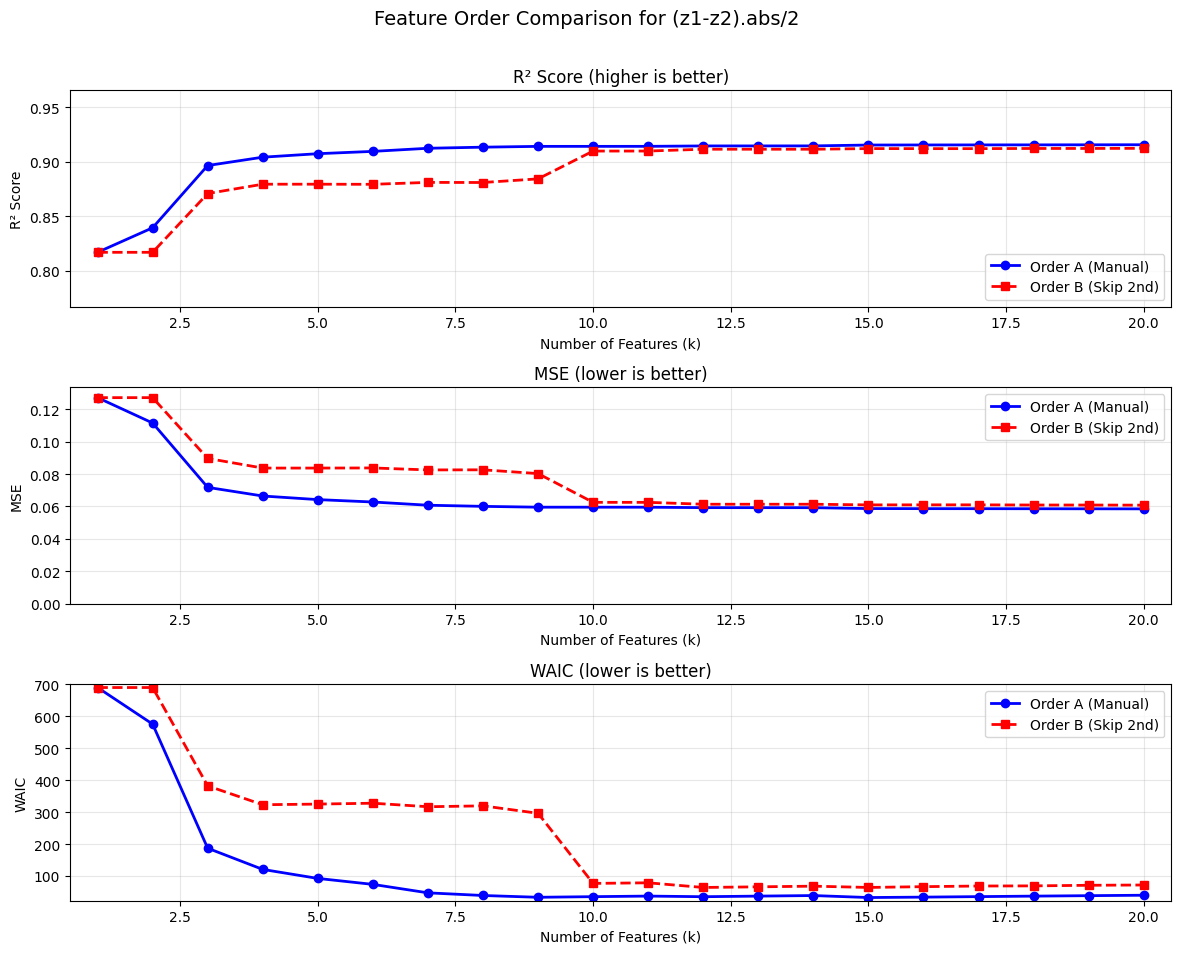

comparison plot saved as：target6_two_orders_comparison_skip3rd.png
metric data saved toCSVfile。


In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_squared_error

# ==============================================================================
# configuration：process only target column 6（index5）
# ==============================================================================
task_idx = 5
target_name = target_names[task_idx]  # should come from an external variable

# get manually adjusted order（final_feature_orders[5]）
manual_order = final_feature_orders[task_idx]  # length 20
print("first five items of manual order：", manual_order[:5])

# define Order A = manual order（original Order B）
order_A = manual_order

# define Order B：based on manual order，but always skip the third feature（index2）
# for each k，actual feature list used = among the first k features in manual order，if it containsL[2]then remove it
def build_order_B_features(k):
    # take the first k items in manual order
    candidates = manual_order[:k]
    # if the third feature is in the candidate list，remove it
    if len(manual_order) > 1 and manual_order[1] in candidates:
        # note：remove the first occurrence only，because the manual order has no duplicates
        candidates.remove(manual_order[1])
    return candidates

# globaly_normformat
if isinstance(y_norm, pd.DataFrame):
    y_norm_array = y_norm.values
else:
    y_norm_array = y_norm
y_task = y_norm_array[:, task_idx] if y_norm_array.ndim == 2 else y_norm_array

# prepare arrays for metrics (20feature counts)
k_range = range(1, 21)
n_k = len(k_range)
scores_A = np.zeros(n_k)
mse_A = np.zeros(n_k)
waic_A = np.zeros(n_k)
scores_B = np.zeros(n_k)
mse_B = np.zeros(n_k)
waic_B = np.zeros(n_k)

# ==============================================================================
# compute metrics for Order A（manual order）
# ==============================================================================
print("\ncompute metrics for Order A...")
for i, k in enumerate(k_range):
    feats = order_A[:k]
    X_k = X[feats].values
    try:
        reg = LassoCV(cv=5, fit_intercept=False, n_jobs=-1, max_iter=10000).fit(X_k, y_task)
        y_pred = reg.predict(X_k)
        scores_A[i] = r2_score(y_task, y_pred)
        mse_A[i] = mean_squared_error(y_task, y_pred)
        # WAICsimplifiedcompute（same as original code）
        log_lik = -0.5 * (np.log(2 * np.pi * mse_A[i]) + (y_task - y_pred)**2 / mse_A[i])
        lppd = np.sum(log_lik)
        waic_A[i] = -2 * (lppd - k)  # use k as the number of effective parameters
    except Exception as e:
        print(f"  orderA k={k} failed: {e}")
        scores_A[i] = mse_A[i] = waic_A[i] = np.nan

# ==============================================================================
# compute metrics for Order B（skipNo. threefeatures）
# ==============================================================================
print("\ncompute metrics for Order B...")
for i, k in enumerate(k_range):
    feats = build_order_B_features(k)
    if len(feats) == 0:
        # in theoryk=1there is at least one feature，but for safety
        scores_B[i] = mse_B[i] = waic_B[i] = np.nan
        continue
    X_k = X[feats].values
    try:
        reg = LassoCV(cv=5, fit_intercept=False, n_jobs=-1, max_iter=10000).fit(X_k, y_task)
        y_pred = reg.predict(X_k)
        scores_B[i] = r2_score(y_task, y_pred)
        mse_B[i] = mean_squared_error(y_task, y_pred)
        log_lik = -0.5 * (np.log(2 * np.pi * mse_B[i]) + (y_task - y_pred)**2 / mse_B[i])
        lppd = np.sum(log_lik)
        # use the actual number of features as the effective parameter count len(feats)
        waic_B[i] = -2 * (lppd - len(feats))
    except Exception as e:
        print(f"  orderB k={k} failed: {e}")
        scores_B[i] = mse_B[i] = waic_B[i] = np.nan

# handle NaN（simply fill with the previous valid value，if none, use0/1/1000）
scores_A = pd.Series(scores_A).fillna(method='ffill').fillna(0).values
mse_A = pd.Series(mse_A).fillna(method='ffill').fillna(1).values
waic_A = pd.Series(waic_A).fillna(method='ffill').fillna(1000).values
scores_B = pd.Series(scores_B).fillna(method='ffill').fillna(0).values
mse_B = pd.Series(mse_B).fillna(method='ffill').fillna(1).values
waic_B = pd.Series(waic_B).fillna(method='ffill').fillna(1000).values

# ==============================================================================
# plot comparison figure（three subplots，two curves in each subplot）
# ==============================================================================
plt.rcParams['font.sans-serif'] = ['Arial', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle(f'Feature Order Comparison for {target_name}', fontsize=14, y=0.95)

x_vals = np.arange(1, 21)

# subplot 1: R²
ax = axes[0]
ax.plot(x_vals, scores_A, marker='o', linestyle='-', color='blue', linewidth=2, markersize=6, label='Order A (Manual)')
ax.plot(x_vals, scores_B, marker='s', linestyle='--', color='red', linewidth=2, markersize=6, label='Order B (Skip 2nd)')
ax.set_xlabel('Number of Features (k)')
ax.set_ylabel('R² Score')
ax.set_xlim(0.5, 20.5)
ax.set_ylim(max(0, min(scores_A.min(), scores_B.min())-0.05), min(1.05, max(scores_A.max(), scores_B.max())+0.05))
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_title('R² Score (higher is better)', fontsize=12)

# subplot 2: MSE
ax = axes[1]
ax.plot(x_vals, mse_A, marker='o', linestyle='-', color='blue', linewidth=2, markersize=6, label='Order A (Manual)')
ax.plot(x_vals, mse_B, marker='s', linestyle='--', color='red', linewidth=2, markersize=6, label='Order B (Skip 2nd)')
ax.set_xlabel('Number of Features (k)')
ax.set_ylabel('MSE')
ax.set_xlim(0.5, 20.5)
ax.set_ylim(0, max(mse_A.max(), mse_B.max())*1.05)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
ax.set_title('MSE (lower is better)', fontsize=12)

# subplot 3: WAIC
ax = axes[2]
ax.plot(x_vals, waic_A, marker='o', linestyle='-', color='blue', linewidth=2, markersize=6, label='Order A (Manual)')
ax.plot(x_vals, waic_B, marker='s', linestyle='--', color='red', linewidth=2, markersize=6, label='Order B (Skip 2nd)')
ax.set_xlabel('Number of Features (k)')
ax.set_ylabel('WAIC')
ax.set_xlim(0.5, 20.5)
waic_min = min(waic_A.min(), waic_B.min())
waic_max = max(waic_A.max(), waic_B.max())
ax.set_ylim(waic_min - 10, waic_max + 10)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
ax.set_title('WAIC (lower is better)', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.94])
save_path = 'target6_two_orders_comparison_skip3rd.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"comparison plot saved as：{save_path}")

# optional：save complete metric data for both orders
df_A = pd.DataFrame({'k': x_vals, 'R2': scores_A, 'MSE': mse_A, 'WAIC': waic_A})
df_B = pd.DataFrame({'k': x_vals, 'R2': scores_B, 'MSE': mse_B, 'WAIC': waic_B})
df_A.to_csv('target6_manual_order_metrics.csv', index=False, encoding='utf-8-sig')
df_B.to_csv('target6_skip3rd_order_metrics.csv', index=False, encoding='utf-8-sig')
print("metric data saved toCSVfile。")